In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv("data.csv")

In [3]:
df.head()

,area_m2,rooms,bedrooms,bathrooms,floor,total_floors,building_age_years,distance_city_center_km,distance_public_transport_km,school_rating,crime_index,parks_within_1km,parking_spaces,renovation_score,energy_efficiency_score,noise_level,neighborhood_income_index,has_elevator,is_new_building,apartment_price_usd
0,64.6,3,2,1,9,25,11.7,3.65,1.18,8.1,29.6,0,1,8.5,8.7,43.2,57.4,1,0,402033.11
1,136.7,6,5,2,3,24,26.5,4.13,0.46,8.7,8.2,3,1,7.5,4.1,44.8,74.5,1,0,716709.88
2,99.5,4,3,1,10,29,8.4,5.69,0.71,6.9,30.2,4,1,7.5,8.6,40.0,73.8,0,0,569233.62
3,86.2,4,3,2,25,30,23.8,13.50,0.44,7.1,40.3,0,1,7.6,6.7,41.2,42.7,1,0,388190.73
4,73.7,2,1,2,1,5,63.1,6.55,2.18,6.9,45.6,1,0,4.6,7.0,46.8,65.4,0,0,296126.18


In [4]:
df.shape

(5000, 20)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   area_m2                       5000 non-null   float64
 1   rooms                         5000 non-null   int64  
 2   bedrooms                      5000 non-null   int64  
 3   bathrooms                     5000 non-null   int64  
 4   floor                         5000 non-null   int64  
 5   total_floors                  5000 non-null   int64  
 6   building_age_years            5000 non-null   float64
 7   distance_city_center_km       5000 non-null   float64
 8   distance_public_transport_km  5000 non-null   float64
 9   school_rating                 5000 non-null   float64
 10  crime_index                   5000 non-null   float64
 11  parks_within_1km              5000 non-null   int64  
 12  parking_spaces                5000 non-null   int64  
 13  renovation_sco

## Helper Functions

#### Splitting data

In [6]:
X = df.drop(columns='apartment_price_usd')
y = df['apartment_price_usd']

n_samples = X.shape[0]

indices = np.random.permutation(n_samples)

X_shuffled = X.iloc[indices]
y_shuffled = y.iloc[indices]

# training set
X_train = X_shuffled[0:4000]
y_train = y_shuffled[0:4000]

# test set 
X_test = X_shuffled[4000:5000]
y_test = y_shuffled[4000:5000]


#### Scaling

In [7]:
def scaling(X_train, X_test):
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)

    # avoidng division by zero
    std[std == 0] = 1

    X_train_stand = (X_train - mean) /std
    X_test_stand = (X_test - mean) /std

    return X_train_stand, X_test_stand

X_train_scaled, X_test_scaled = scaling(X_train, X_test)

#### Metrics Functions

In [ ]:
def MeanSquaredError(y_true, y_pred):
    """
    Formula: MSE = (1 / n) * Σ(y_pred - y_true)²
    Meaning:
        y_true: Actual Value
        y_pred: Predicted Value
        error: Difference between predicted and actual value
        n : Number of samples
        Σ : Summation of all the squared errors
    Mean Squared Error measures the average squared difference between real and predicted values. 
    Why do we need square error: 
        without square, positive and negative errors can cancel each other. 
    MSE punishes larger errors strongly, making it sensitive to outliers.
    """
    y_true = np.array(y_true, dtype=float).ravel()
    y_pred = np.array(y_pred, dtype=float).ravel()

    if len(y_true) != len(y_pred):
        raise ValueError("The length of y_true and y_pred must be the same.")

    n = len(y_true)
    total_squared_error = 0

    for i in range(n):
        error = y_pred[i] - y_true[i]
        squared_error = error ** 2
        total_squared_error += squared_error

    mse = total_squared_error / n
    return mse

def MeanAbsoluteError(y_true, y_pred):
    """
    Formula: MAE = (1 / n) * Σ |y_pred - y_true|
    Meaning:
        y_true  = actual value
        y_pred  = predicted value
        error   = y_pred - y_true
        |error| = absolute error
        n       = number of samples
        Σ       = sum
    Mean Absolute Error measures the average absolute difference between real and predicted values.
    """
    y_true = np.array(y_true, dtype=float).ravel()
    y_pred = np.array(y_pred, dtype=float).ravel()

    if len(y_true) != len(y_pred):
        raise ValueError("The length of y_true and y_pred must be the same.")

    n = len(y_true)
    total_absolute_error = 0

    for i in range(n):
        error = abs(y_pred[i] - y_true[i])
        total_absolute_error += error

    mae = total_absolute_error / n
    return mae

def RootMeanSquaredError(y_true, y_pred):
    """
    Formula: RMSE = sqrt((1 / n) * Σ(y_pred - y_true)²)
    Meaning:
        y_true: Actual Value
        y_pred: Predicted Value
        error: Difference between predicted and actual value
        n : Number of samples
        Σ : Summation of all the squared errors
    Root Mean Squared Error is the Square root of Mean Squared eror. 
    """
    mse = MeanSquaredError(y_true, y_pred)
    rmse = np.sqrt(mse)
    return rmse

def HuberLoss(y_true, y_pred, delta=1.0):
    """
    Formula:
        if |error| <= delta:
            Huber Loss = 0.5 * error²
        if |error| > delta:
            Huber Loss = delta * (|error| - 0.5 * delta)
    Meaning:
        y_true : Actual value
        y_pred : Predicted value
        error  : y_pred - y_true
        delta  : Threshold that controls transition between MSE and MAE
        n      : Number of samples
        Σ      : Summation
    Huber Loss combines Mean Squared Error and Mean Absolute Error.
    For small errors:
        It behaves like MSE and uses squared error.
    For large errors:
        It behaves like MAE and uses linear error.
    This makes Huber Loss less sensitive to outliers than MSE.
    """
    y_true = np.array(y_true, dtype=float).ravel()
    y_pred = np.array(y_pred, dtype=float).ravel()

    if len(y_true) != len(y_pred):
        raise ValueError("the length of y_true and y_pred must be the same")
    if delta <= 0:
        raise ValueError("delta must be greater than 0")
    n = len(y_true)
    total_huber_loss = 0
    for i in range(n):
        error = y_pred[i] - y_true[i]
        if abs(error) <= delta:
            loss = 0.5 * error ** 2
        else:
            loss = delta * (abs(error) - 0.5 * delta)
        total_huber_loss += loss
    mean_huber_loss = total_huber_loss / n
    return mean_huber_loss

def R2Score(y_true, y_pred):
    """
    Formula: R² = 1 - (Σ(y_true - y_pred)² / Σ(y_true - mean(y_true))²)
    Meaning:
        y_true: Actual Value
        y_pred: Predicted Value
        mean(y_true): Mean of actual values
        Σ: Summation of all the squared errors
    R² = 1 - (SS_res / SS_total)
        SS_res   = sum of squared residuals/errors
        SS_total = total variation in actual values
    R² compares trained model with a very simple baseline model. 
    How to Interpret R²:
        R² = 1.0     → perfect model
        R² = 0.8     → model explains 80% of variation (How much the real target values are spread out or different from their average.)
        R² = 0.5     → model explains 50% of variation
        R² = 0       → model is not better than predicting the mean
        R² < 0       → model is worse than predicting the mean
    """
    y_true = np.array(y_true, dtype=float).ravel()
    y_pred = np.array(y_pred, dtype=float).ravel()

    if len(y_true) != len(y_pred):
        raise ValueError("The length of y_true and y_pred must be the same.")

    mean_y_true = np.mean(y_true)
    total_variance = np.sum((y_true - mean_y_true) ** 2)
    unexpained_variance = np.sum((y_true - y_pred) ** 2)

    r2_score = 1 - (unexpained_variance / total_variance)
    
    return r2_score

#### Model

In [9]:
class LinearRegression:
    def __init__(
            self, 
            learning_rate=0.01, 
            iterations=100, 
            cost_function='mse', 
            delta=100
        ):
        self.learning_rate=learning_rate
        self.iterations = iterations
        self.cost_function = cost_function
        self.delta = delta
        # training history
        self.mae_scores = []
        self.mse_scores = []
        self.huber_scores = []
        self.rmse_scores = []


    def fit(self, X, y):
        # converting data to numpy array
        X = np.asarray(X, dtype=float)
        # converting target 1D array 
        y = np.asarray(y, dtype=float).ravel()
        # num of data samples, and num of featues
        n_samples, n_features = X.shape

        # initialization of weights and bias
        self.weights = np.zeros(n_features)
        if self.cost_function == 'mae':
            self.bias = np.median(y)
        else:
            self.bias = 0            

        # updating weights and bias in n iterations
        for iterration in range(self.iterations):
            # making predictions 
            y_pred = np.dot(X, self.weights)+self.bias
            # error 
            error = y_pred - y
            # derivatives calculation
            if self.cost_function == 'mse':
                # Mean Squared Error
                dw = (1 / n_samples) * np.dot(X.T, error) 
                db = (1 / n_samples) * np.sum(error)
            elif self.cost_function == 'mae':
                # Mean Absolute Error
                dw = (1 / n_samples) * np.dot(X.T, np.sign(error)) 
                db = (1 / n_samples) * np.sum(np.sign(error))
            elif self.cost_function == 'huber':
                huber_loss = np.where(
                    np.abs(error) <= self.delta,
                    error,
                    self.delta * np.sign(error)
                )
                dw = (1 / n_samples) * np.dot(X.T, huber_loss)
                db = (1 / n_samples) * np.sum(huber_loss)
            else: 
                raise ValueError("Cost function must be 'mse' or 'mae' or 'huber'")

            # updating weights 
            self.weights = self.weights - self.learning_rate * dw 
            self.bias = self.bias - self.learning_rate * db

            # make predictions with updated weights
            y_pred_updated = np.dot(X, self.weights) + self.bias

            # calculate and store MAE
            mae = MeanAbsoluteError(y, y_pred_updated)
            self.mae_scores.append([iterration, mae])

            # calculate and store MSE
            mse = MeanSquaredError(y, y_pred_updated)
            self.mse_scores.append([iterration, mse])

            # calculate and store Huber loss
            huber_loss = HuberLoss(y, y_pred_updated, delta=self.delta)
            self.huber_scores.append([iterration, huber_loss])

            # calculate and store RMSE 
            rmse = RootMeanSquaredError(y, y_pred_updated)
            self.rmse_scores.append([iterration, rmse])
                
      
    def predict(self, X_new):
        return np.dot(X_new, self.weights) + self.bias


## Requirements on data to apply Linear Regression

### 1. Linearity 

#### Scatter plots to detect Linearity in Data

In [10]:
df_columns = [
    'area_m2',
    'rooms',
    'bedrooms',
    'bathrooms',
    'floor',
    'total_floors',
    'building_age_years',
    'distance_city_center_km',
    'distance_public_transport_km',
    'school_rating',
    'crime_index',
    'parks_within_1km',
    'parking_spaces',
    'renovation_score',
    'energy_efficiency_score',
    'noise_level',
    'neighborhood_income_index',
    'has_elevator',
    'is_new_building'
]

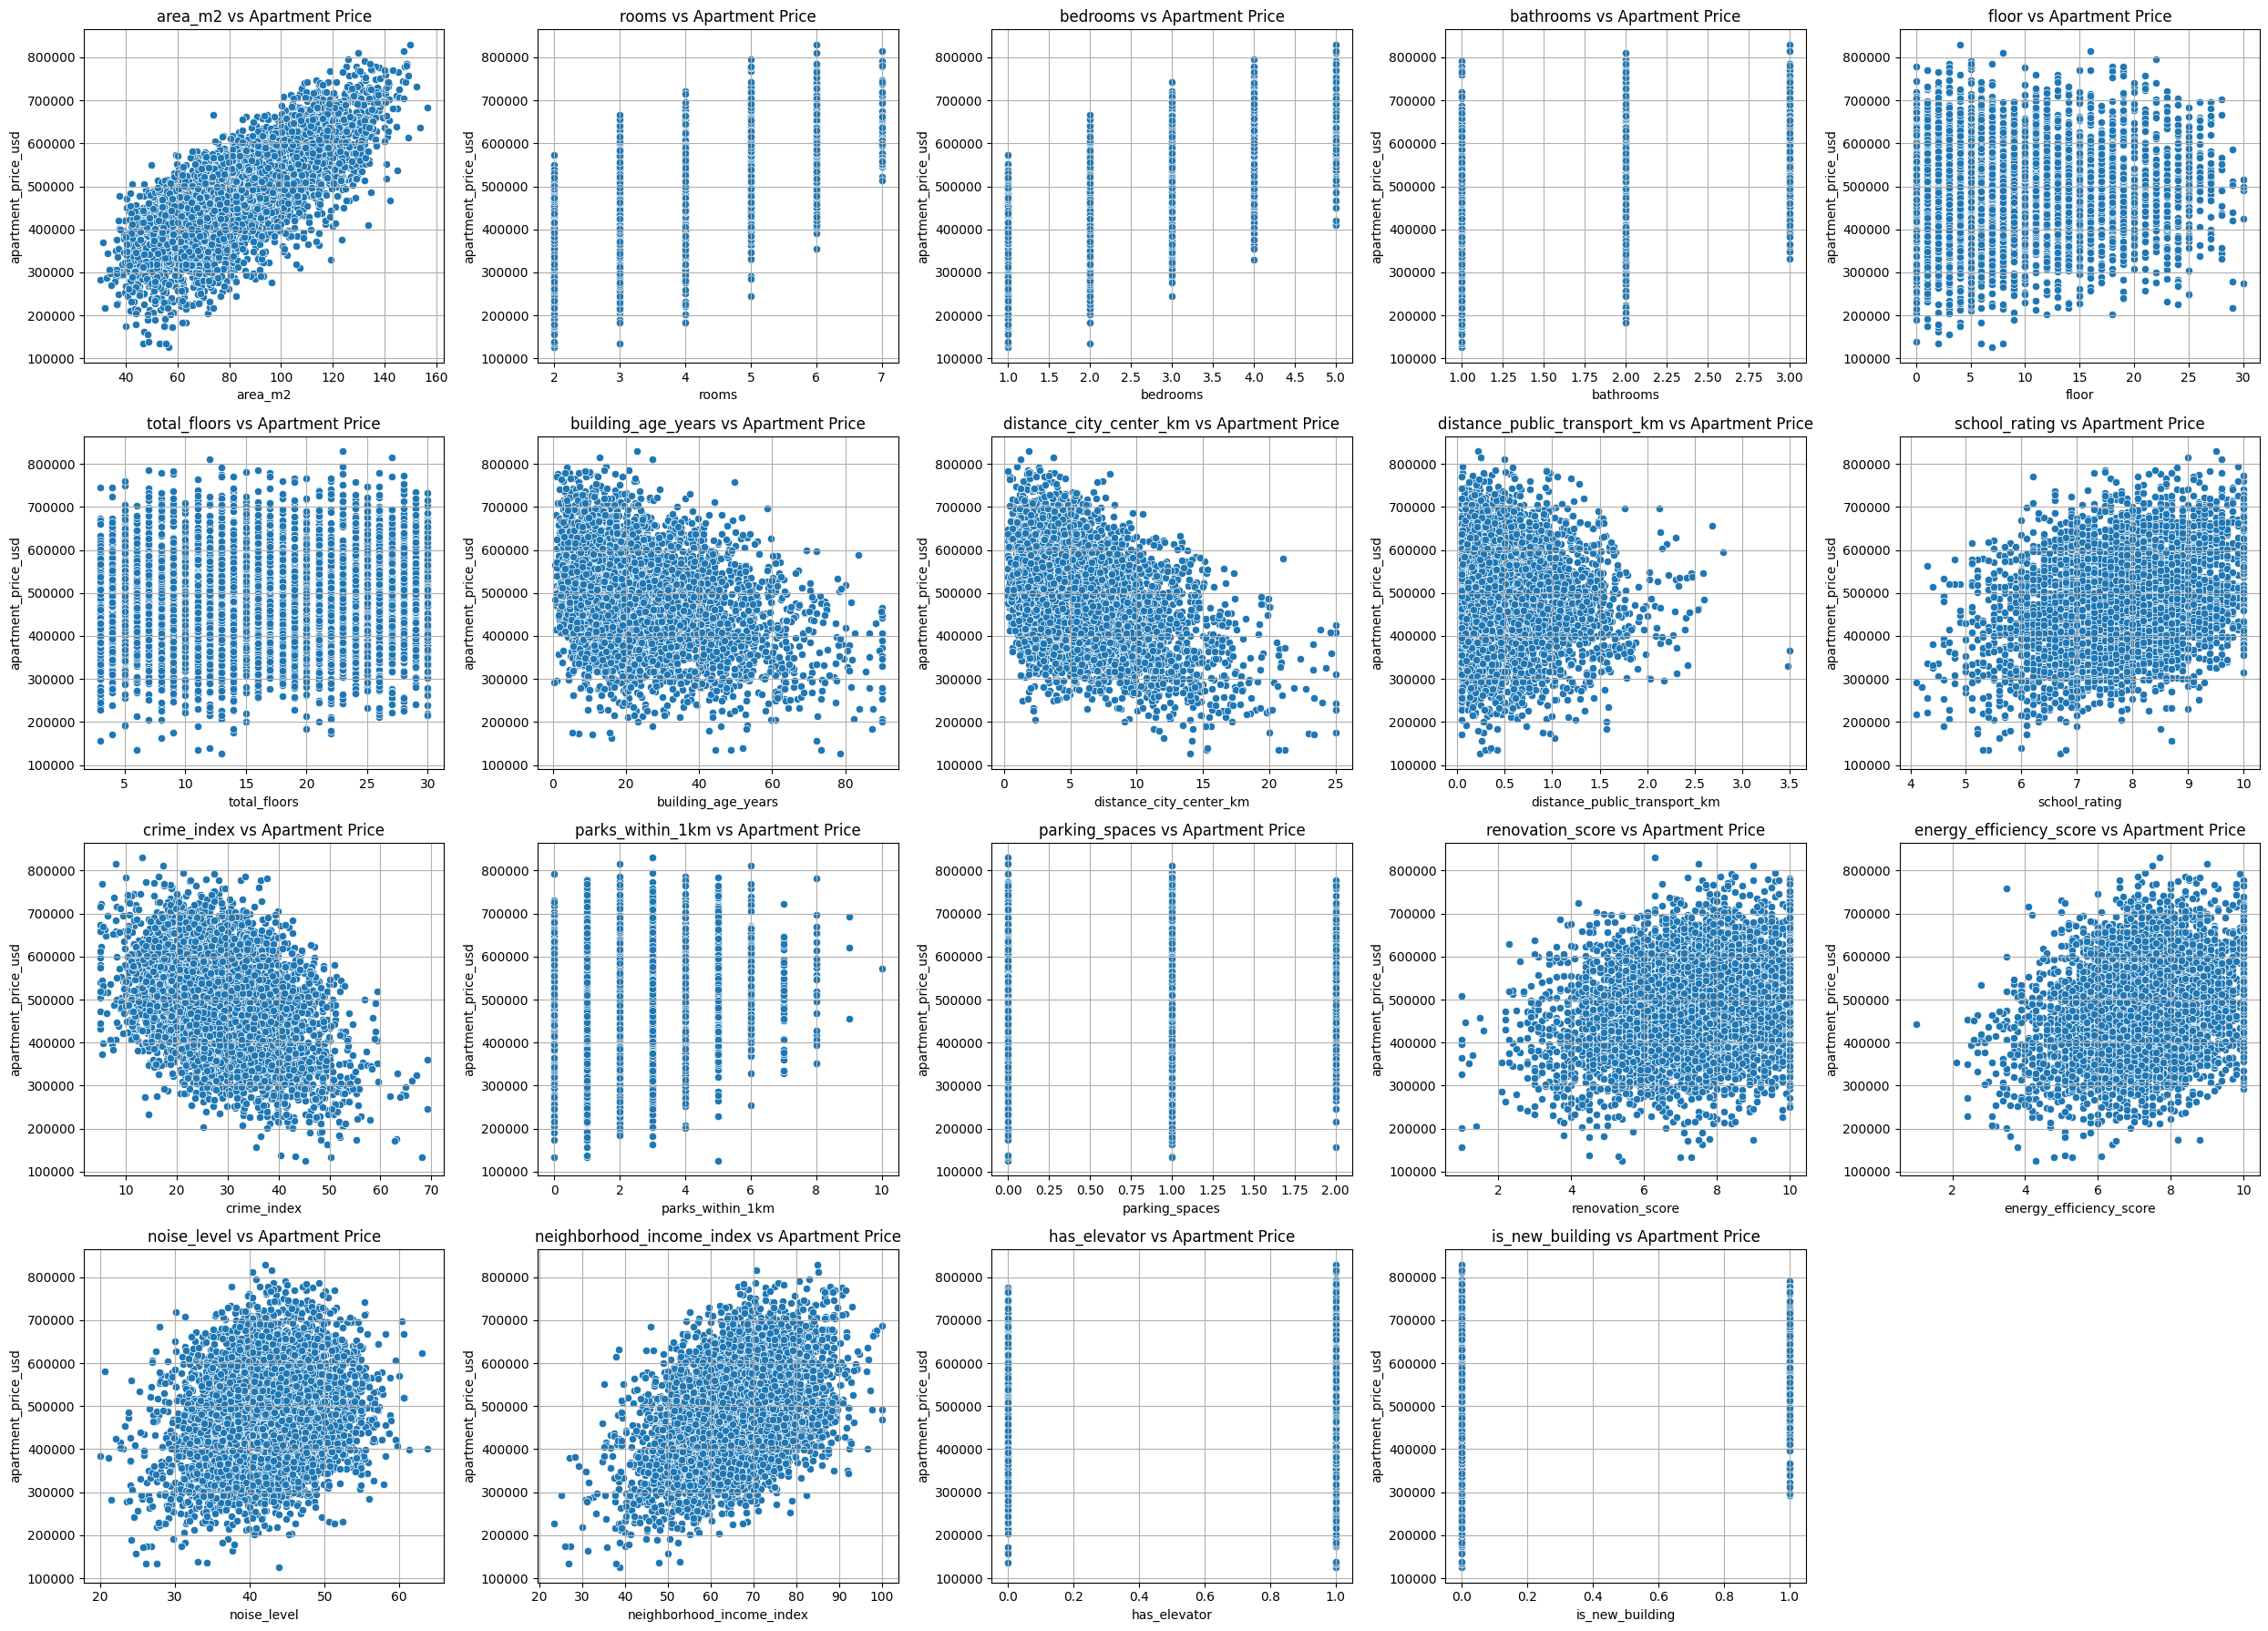

In [11]:
fig, axes = plt.subplots(
    nrows=4,
    ncols=5,
    figsize=(25, 18)
)

axes = axes.flatten()


for i, col in enumerate(df_columns):

    sns.scatterplot(
        data=df,
        x=col,
        y='apartment_price_usd',
        ax=axes[i]
    )

    axes[i].set_title(
        f'{col} vs Apartment Price'
    )

    axes[i].grid()


# remove unused subplot
for i in range(len(df_columns), len(axes)):
    fig.delaxes(axes[i])


plt.tight_layout()
plt.show()

The Feature columns that have approximate linear relationships with Target column apartment_price_usd
- **area_m2**
- **crime_index**
- **neighborhood_income_index**
- **school_rating**
- **rooms**
- **bedrooms**
- **distance_public_transport_km**
- **renovation_score**
- **energy_efficiency_score**

The Feature columns that may contain nonlinearity with Target column apartment_price_usd
- **building_age_years**
- **distance_city_center_km**
- **noise_level**

The Feature columns that have weak, unclear, or discrete relationships with Target column apartment_price_usd and require further analysis
- **floor**
- **total_floors**
- **bathrooms**
- **parks_within_1km**
- **parking_spaces**

The Binary Feature columns
- **has_elevator**
- **is_new_building**

### 2. Normality of Residuals

In [12]:
model = LinearRegression(
    learning_rate=0.01,
    iterations=1000,
    cost_function='mse'
)
model.fit(X_train_scaled, y_train)

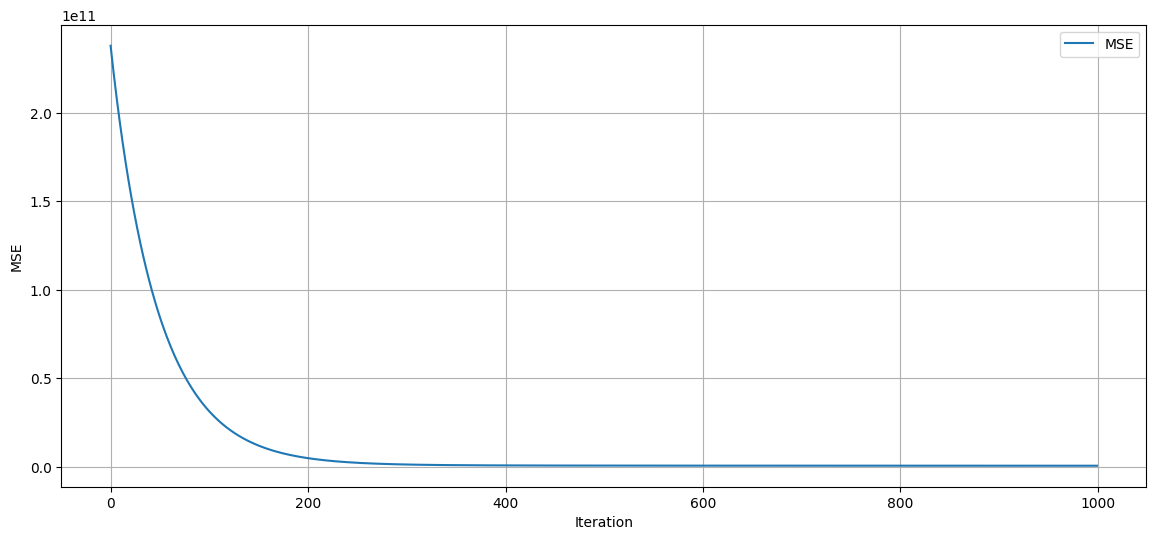

In [13]:
iterations = [item[0] for item in model.mse_scores]
mae_costs = [item[1] for item in model.mse_scores]

plt.figure(figsize=(14, 6))
plt.plot(iterations, mae_costs, label='MSE')
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.legend()
plt.grid()
plt.show()

In [14]:
predictions = model.predict(X_test_scaled)
residuals = y_test - predictions

#### Visualizations

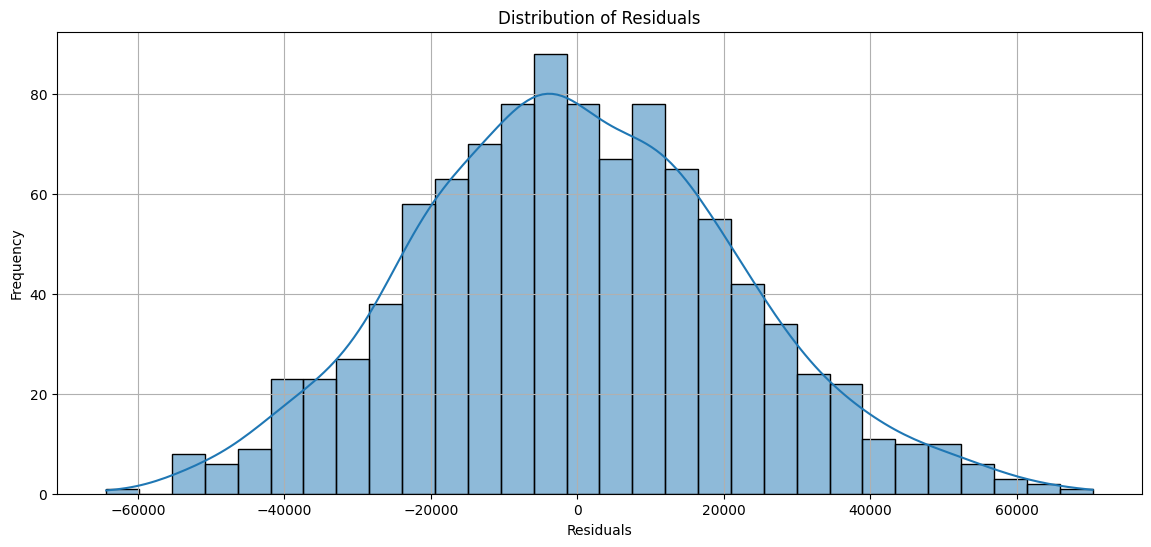

In [15]:
plt.figure(figsize=(14, 6))

sns.histplot(
    residuals,
    kde=True,
    bins=30
)

plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid()
plt.show()

The residuals are approximately bell-shaped and centered abour 0. Most residuals are between -40,000 and +40,000. There are some large residuals in both left and right tails/

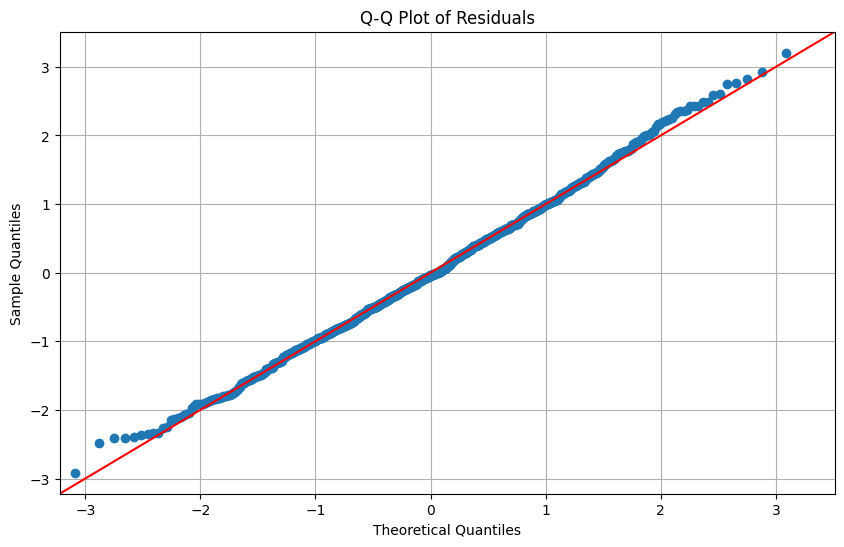

In [16]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

sm.qqplot(
    residuals,
    line='45',
    fit=True,
    ax=ax
)

ax.set_title('Q-Q Plot of Residuals')
ax.grid()

plt.show()

From the Q-Q plot, most residual points lie close to the diagonal reference line. This indicates that the residuals are approximately normally distributed. There are small deviations at the extreme tails, but they are not severe. Therefore, based on the Q-Q plot, the normality of residuals assumption is reasonably satisfied.

#### Summary statistics methods: Skewness, Kurtosis

Skewness

In [17]:
def skewness(values):
    n = len(values)
    mean = values.sum() / n 
    std = values.std()
    sum_values = 0
    for i in values:
        diff = i - mean
        sum_values += (diff / std) ** 3

    return sum_values / n

In [18]:
residuals_skewness = skewness(residuals)
residuals_skewness

np.float64(0.15221710989938567)

In [19]:
from scipy.stats import skew

skew(residuals)

np.float64(0.15244572130466585)

The residuals have very low skewness value 0.008, meaning it is approximately symmetric. This supports the normality of residuals

Peason Kurtosis

In [20]:
def kurtosis(values):
    n = len(values)
    mean = values.sum() / n
    std = values.std()
    sum_values = 0
    for i in values:
        diff = i - mean
        sum_values += (diff / std) ** 4
    return sum_values / n

In [21]:
residuals_pearson_kurtosis = kurtosis(residuals)
residuals_pearson_kurtosis

np.float64(2.9195234768252734)

In [22]:
from scipy.stats import kurtosis
fisher_kurtosis = kurtosis(residuals, fisher=False)
fisher_kurtosis

np.float64(2.9253712940420575)

In [23]:
fisher_kurtosis = kurtosis(residuals)
fisher_kurtosis

np.float64(-0.07462870595794246)

Pearson kurtosis is approximately 2.89, which is close to 3 and supports a mesokurtic distribution similar to the normal distribution.

Fisher kurtosis is approximately -0.109, which is close to 0 but slightly negative. This suggests the residuals are very slightly platykurtic, meaning they have slightly lighter tails than a normal distribution. However, since the value is very close to 0, the tail behavior is still approximately normal.

#### Statistical test methods: Jarque-Bera test or Shapiro-Wilk test

### 3. Non-collinearity:

#### Collinearity

##### 1. scatter plots

In [24]:
feature_cols = ['area_m2', 'rooms', 'bedrooms', 'bathrooms', 'floor', 'total_floors',
       'building_age_years', 'distance_city_center_km',
       'distance_public_transport_km', 'school_rating', 'crime_index',
       'parks_within_1km', 'parking_spaces', 'renovation_score',
       'energy_efficiency_score', 'noise_level', 'neighborhood_income_index',
       'has_elevator', 'is_new_building']
df[feature_cols].head()

,area_m2,rooms,bedrooms,bathrooms,floor,total_floors,building_age_years,distance_city_center_km,distance_public_transport_km,school_rating,crime_index,parks_within_1km,parking_spaces,renovation_score,energy_efficiency_score,noise_level,neighborhood_income_index,has_elevator,is_new_building
0,64.6,3,2,1,9,25,11.7,3.65,1.18,8.1,29.6,0,1,8.5,8.7,43.2,57.4,1,0
1,136.7,6,5,2,3,24,26.5,4.13,0.46,8.7,8.2,3,1,7.5,4.1,44.8,74.5,1,0
2,99.5,4,3,1,10,29,8.4,5.69,0.71,6.9,30.2,4,1,7.5,8.6,40.0,73.8,0,0
3,86.2,4,3,2,25,30,23.8,13.50,0.44,7.1,40.3,0,1,7.6,6.7,41.2,42.7,1,0
4,73.7,2,1,2,1,5,63.1,6.55,2.18,6.9,45.6,1,0,4.6,7.0,46.8,65.4,0,0


by intuiton and logic, I choose the following feature column pairs
1. Apartment size and room structure
- **area_m2** ↔ **rooms**
- **area_m2** ↔ **bedrooms**
- **area_m2** ↔ **bathrooms**
- **rooms** ↔ **bedrooms**
- **rooms** ↔ **bathrooms**
- **bedrooms** ↔ **bathrooms**

2. Building structure
- **floor** ↔ **total_floors**
- **building_age_years** ↔ **is_new_building**
- **building_age_years** ↔ **energy_efficiency_score**

3. Location and socioeconomic features
- **distance_city_center_km** ↔ **crime_index**
- **distance_city_center_km** ↔ **neighborhood_income_index**
- **distance_city_center_km** ↔ **noise_level**
- **crime_index** ↔ **neighborhood_income_index**

In [25]:
pairs_to_check = [
    ('area_m2', 'rooms'),
    ('area_m2', 'bedrooms'),
    ('area_m2', 'bathrooms'),
    ('rooms', 'bedrooms'),
    ('rooms', 'bathrooms'),
    ('bedrooms', 'bathrooms'),
    ('floor', 'total_floors'),
    ('building_age_years', 'is_new_building'),
    ('building_age_years', 'energy_efficiency_score'),
    ('distance_city_center_km', 'crime_index'),
    ('distance_city_center_km', 'neighborhood_income_index'),
    ('crime_index', 'neighborhood_income_index')
]

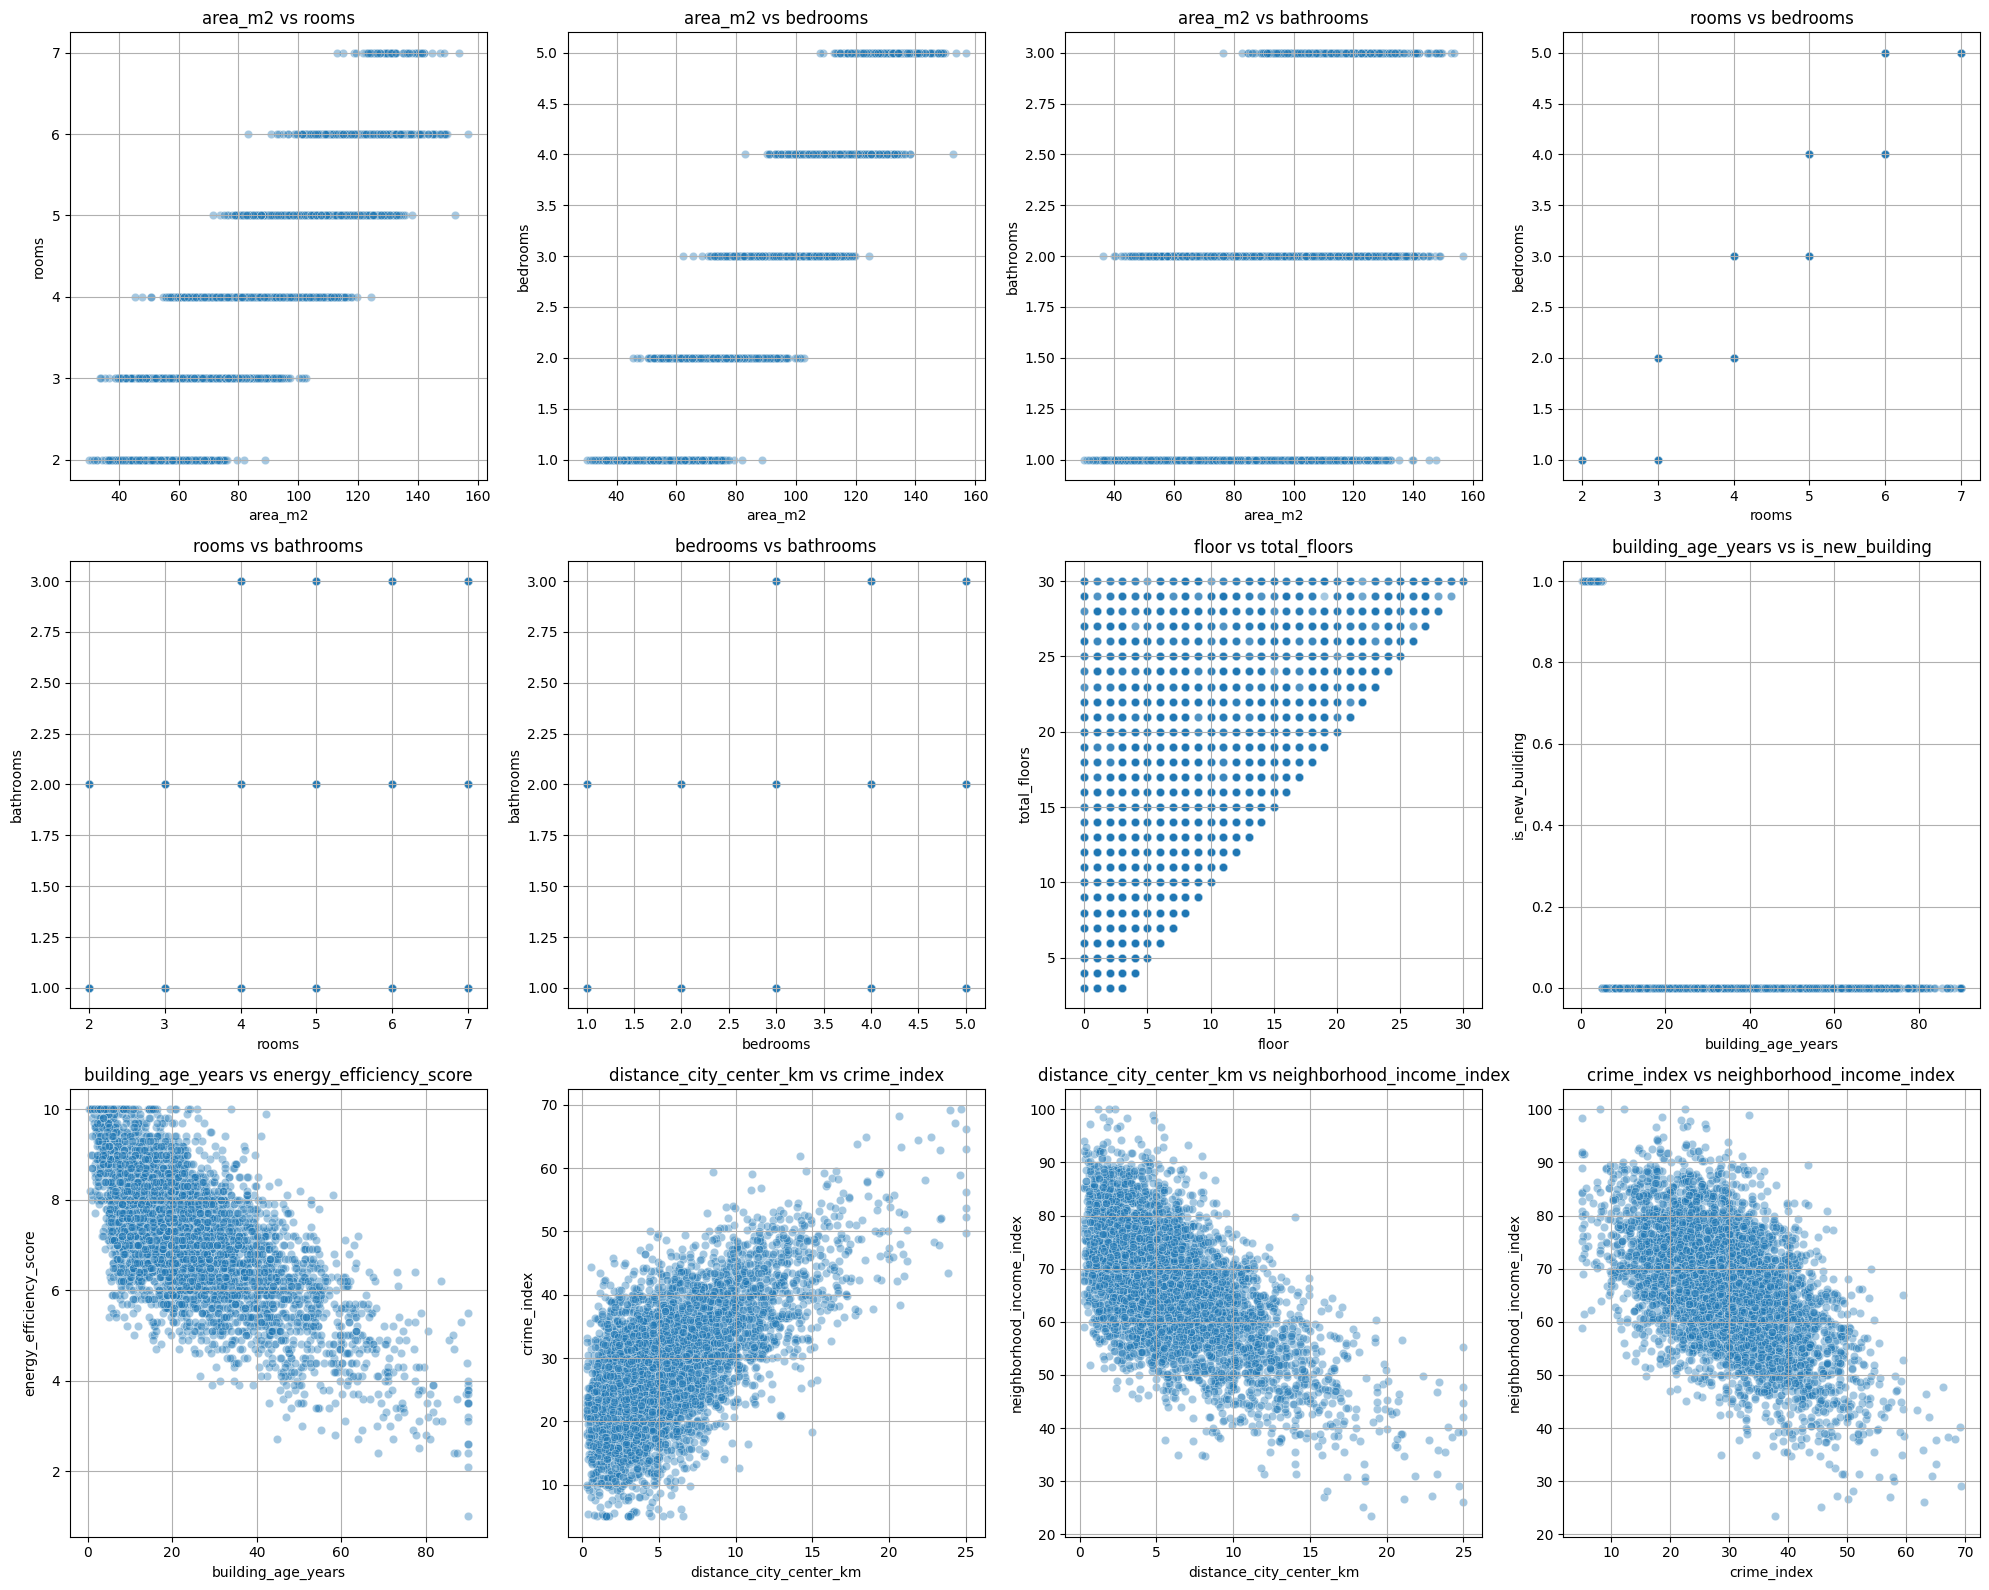

In [26]:
fix, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(20, 16)
)
axes = axes.flatten()
for i, (feature_1, feature_2) in enumerate(pairs_to_check):
    sns.scatterplot(
        data=df,
        x=feature_1,
        y=feature_2,
        ax=axes[i],
        alpha=0.4
    )
    axes[i].set_title(f"{feature_1} vs {feature_2}")
    axes[i].grid()
plt.tight_layout()
plt.show()

From the scatter plots, we can observe the following:

1. There is clear pairwise collinearity among the following feature pairs:

- **rooms** ↔ **bedrooms**
- **area_m2** ↔ **bedrooms**
- **area_m2** ↔ **rooms**

These features all describe apartment size and room structure, so they carry overlapping information.

****

2. There are noticeable relationships between the following feature pairs:

- **building_age_years** ↔ **energy_efficiency_score**
- **distance_city_center_km** ↔ **crime_index**
- **distance_city_center_km** ↔ **neighborhood_income_index**
- **crime_index** ↔ **neighborhood_income_index**

These relationships are not necessarily severe collinearity problems, but they should be checked further using correlation values and VIF.

****

3. There is weak to moderate pairwise collinearity among the following feature pairs:

- **area_m2** ↔ **bathrooms**
- **rooms** ↔ **bathrooms**
- **bedrooms** ↔ **bathrooms**
- **floor** ↔ **total_floors**
- **building_age_years** ↔ **is_new_building**

These relationships are weaker or less clear from the scatter plots, so they are not the main collinearity concern at this stage.

****

##### 2.Correlation

In [27]:
feature_cols

['area_m2',
 'rooms',
 'bedrooms',
 'bathrooms',
 'floor',
 'total_floors',
 'building_age_years',
 'distance_city_center_km',
 'distance_public_transport_km',
 'school_rating',
 'crime_index',
 'parks_within_1km',
 'parking_spaces',
 'renovation_score',
 'energy_efficiency_score',
 'noise_level',
 'neighborhood_income_index',
 'has_elevator',
 'is_new_building']

In [28]:
corr_matrix = df[feature_cols].corr()
corr_matrix

,area_m2,rooms,bedrooms,bathrooms,floor,total_floors,building_age_years,distance_city_center_km,distance_public_transport_km,school_rating,crime_index,parks_within_1km,parking_spaces,renovation_score,energy_efficiency_score,noise_level,neighborhood_income_index,has_elevator,is_new_building
area_m2,1.000000,0.868004,0.929603,0.591807,0.006587,0.009523,-0.005182,0.013712,-0.006748,0.018666,-0.001780,0.017636,0.013515,0.017651,-0.002432,-0.014588,-0.014293,-0.005235,0.000811
rooms,0.868004,1.000000,0.934035,0.459398,0.007911,0.010672,0.004533,0.022408,-0.003624,0.017166,0.006408,0.022913,-0.001109,0.013047,-0.002940,-0.015004,-0.019869,0.001490,-0.002439
bedrooms,0.929603,0.934035,1.000000,0.493297,0.012654,0.014089,-0.002699,0.012776,-0.000164,0.015534,-0.003461,0.013940,0.006754,0.015584,-0.001935,-0.009693,-0.013535,0.003202,-0.002256
bathrooms,0.591807,0.459398,0.493297,1.000000,0.005654,-0.007512,0.011639,0.012733,-0.007958,0.014731,0.001724,0.005365,0.016789,-0.009108,-0.017183,-0.003071,-0.021003,-0.019973,0.001200
floor,0.006587,0.007911,0.012654,0.005654,1.000000,0.590212,-0.010152,-0.022819,0.013336,0.002942,-0.018742,0.036440,0.006283,0.010862,0.005416,0.287173,0.026962,0.134901,0.018101
total_floors,0.009523,0.010672,0.014089,-0.007512,0.590212,1.000000,-0.003603,-0.018334,0.003475,-0.016973,-0.016765,0.025749,-0.019468,-0.000873,0.001171,0.184708,0.016137,0.217667,0.016380
building_age_years,-0.005182,0.004533,-0.002699,0.011639,-0.010152,-0.003603,1.000000,0.008505,0.022382,0.005133,-0.009442,-0.006113,0.002471,-0.589977,-0.696710,-0.003552,0.012321,0.016407,-0.305049
distance_city_center_km,0.013712,0.022408,0.012776,0.012733,-0.022819,-0.018334,0.008505,1.000000,-0.001779,-0.430792,0.654805,-0.265624,0.006171,0.012797,-0.012864,-0.528474,-0.626744,0.003322,-0.002653
distance_public_transport_km,-0.006748,-0.003624,-0.000164,-0.007958,0.013336,0.003475,0.022382,-0.001779,1.000000,0.017060,-0.011654,-0.037177,0.003306,-0.002797,0.003297,0.022505,0.019975,0.000463,0.009942
school_rating,0.018666,0.017166,0.015534,0.014731,0.002942,-0.016973,0.005133,-0.430792,0.017060,1.000000,-0.448448,0.117418,-0.001486,-0.011688,0.004923,0.212081,0.478671,-0.013682,-0.010932


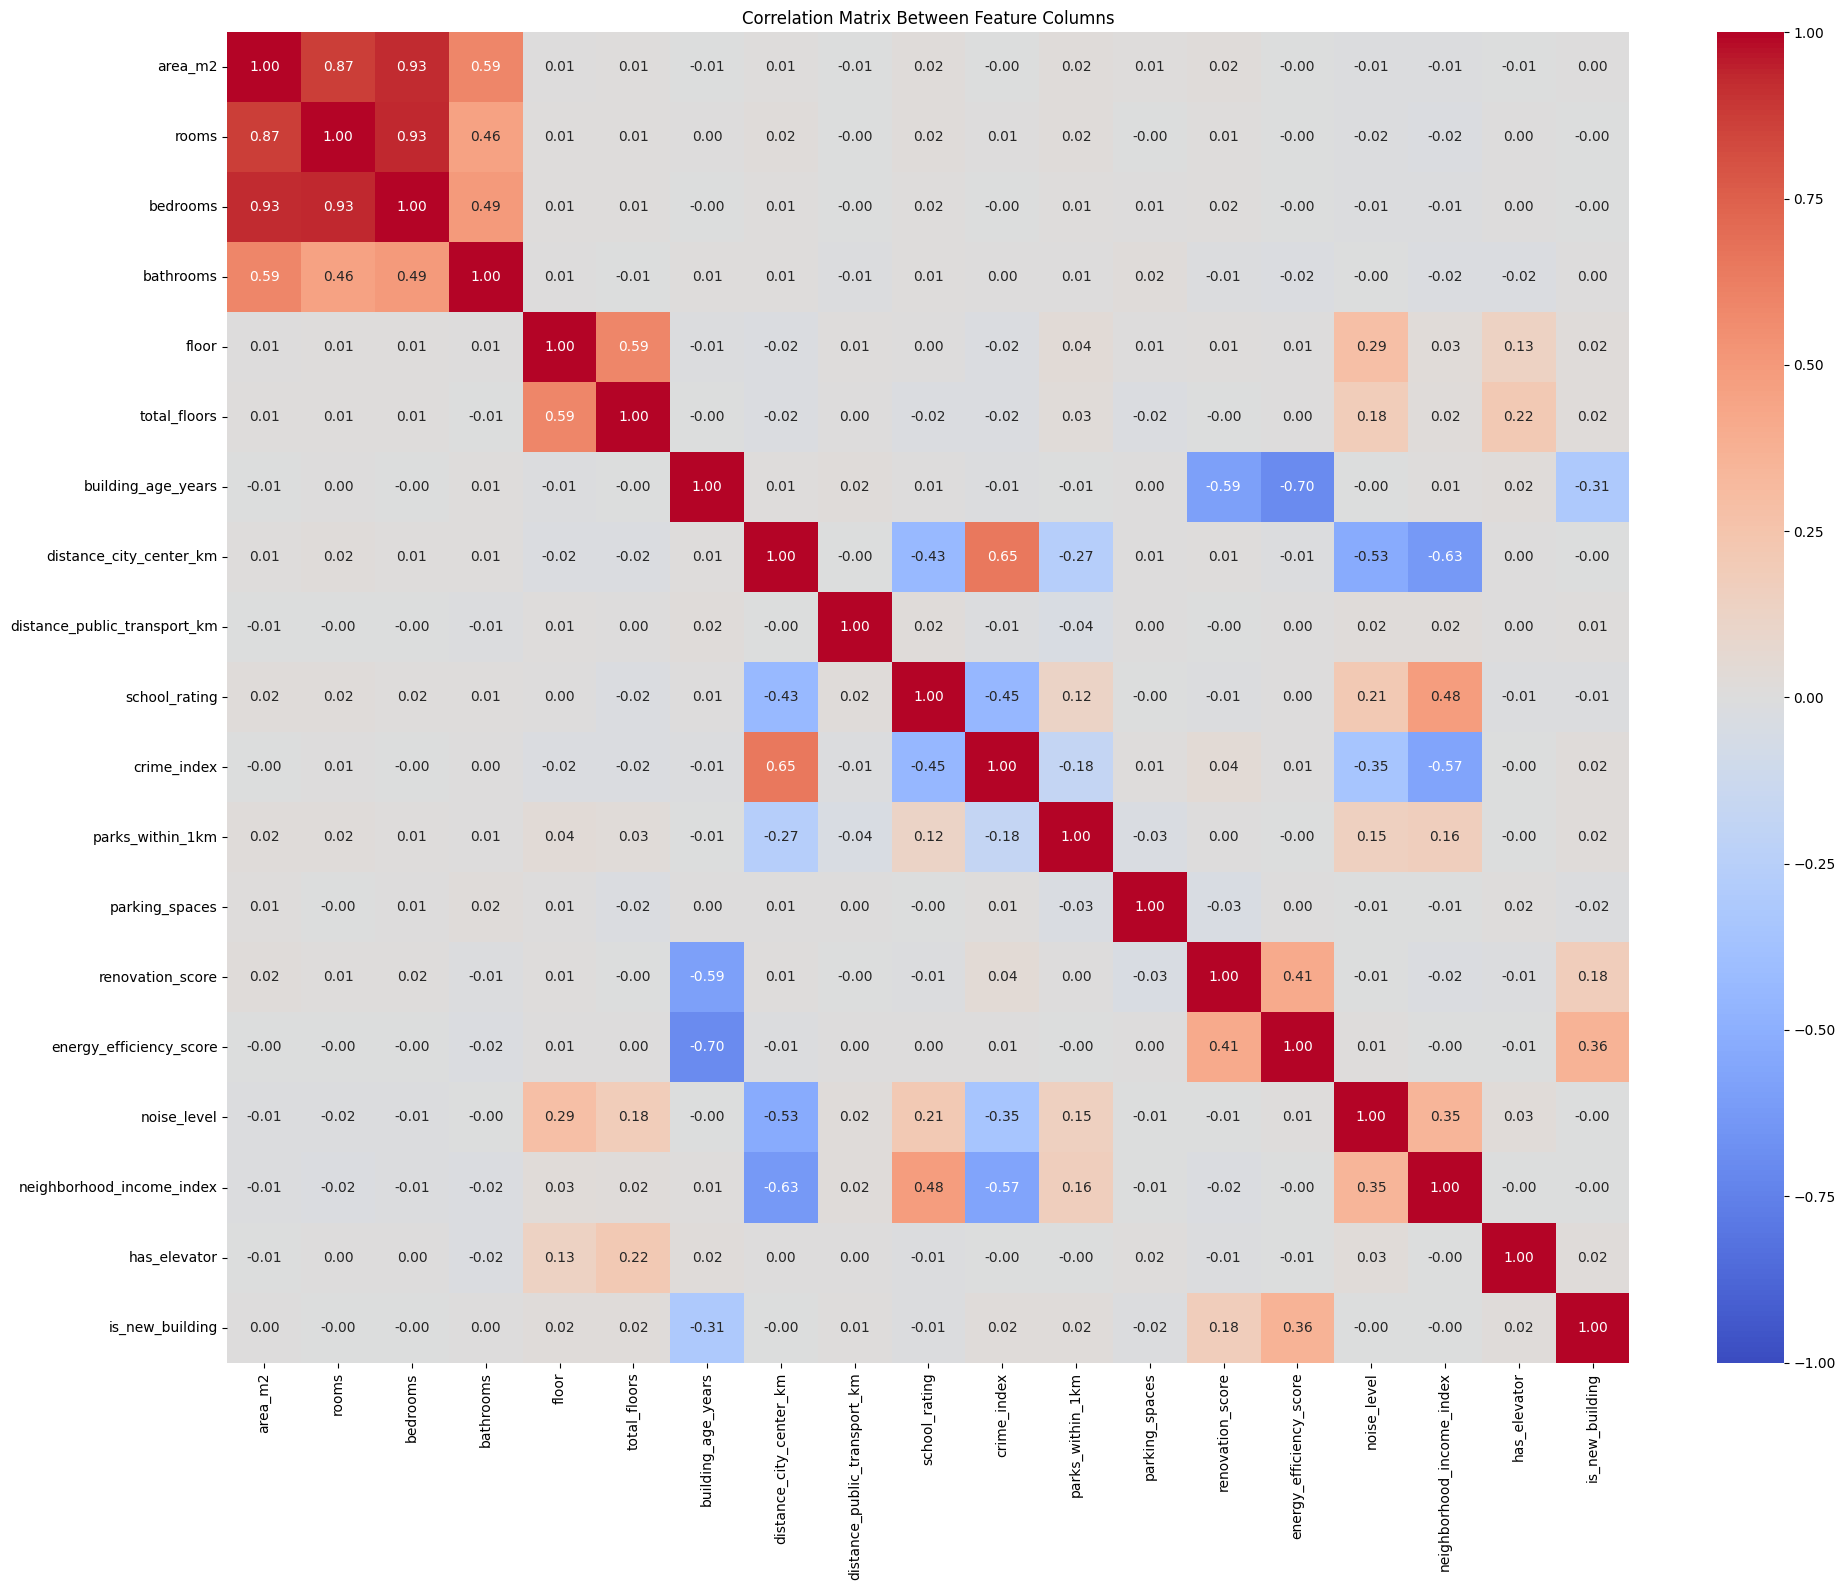

In [29]:
plt.figure(figsize=(20, 16))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1
)

plt.title('Correlation Matrix Between Feature Columns')
plt.tight_layout()
plt.show()

In [30]:
upper_triangle = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)
correlation_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)
correlation_pairs.columns = [
    'feature_1',
    'feature_2',
    'correlation'
]
correlation_pairs['abs_correlation'] = (
    correlation_pairs['correlation'].abs()
)
strong_corr_pairs = correlation_pairs[
    correlation_pairs['abs_correlation'] >= 0.7
].sort_values(
    by='abs_correlation',
    ascending=False
)
strong_corr_pairs


,feature_1,feature_2,correlation,abs_correlation
21,rooms,bedrooms,0.934035,0.934035
2,area_m2,bedrooms,0.929603,0.929603
1,area_m2,rooms,0.868004,0.868004


In [31]:
moderate_corr_pairs = correlation_pairs[
    (correlation_pairs['abs_correlation'] >= 0.5) &
    (correlation_pairs['abs_correlation'] < 0.7)
]
moderate_corr_pairs

,feature_1,feature_2,correlation,abs_correlation
3,area_m2,bathrooms,0.591807,0.591807
81,floor,total_floors,0.590212,0.590212
127,building_age_years,renovation_score,-0.589977,0.589977
128,building_age_years,energy_efficiency_score,-0.696710,0.696710
143,distance_city_center_km,crime_index,0.654805,0.654805
148,distance_city_center_km,noise_level,-0.528474,0.528474
149,distance_city_center_km,neighborhood_income_index,-0.626744,0.626744
206,crime_index,neighborhood_income_index,-0.569012,0.569012


From the correlation matrix, strong pairwise collinearity is detected among:


- **rooms** ↔ **bedrooms**: correlation ≈ 0.934
- **area_m2** ↔ **bedrooms**: correlation ≈ 0.930
- **area_m2** ↔ **rooms**: correlation ≈ 0.868

These features all describe apartment size and room structure, so they contain overlapping information.

Moderate relationships are also detected among:

- **building_age_years** ↔ **energy_efficiency_score**
- **distance_city_center_km** ↔ **crime_index**
- **distance_city_center_km** ↔ **neighborhood_income_index**
- **area_m2** ↔ **bathrooms**
- **floor** ↔ **total_floors**
- **crime_index** ↔ **neighborhood_income_index**

The main pairwise collinearity problem is between **area_m2**, **rooms**, and **bedrooms**.

#### Multicollinearity

In [32]:
feature_cols
X_mult = df[feature_cols]

##### 1. VIF method

In [33]:
import statsmodels.api as sm 
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [34]:
x_vif_const = sm.add_constant(X_mult)

In [35]:
vif_df = pd.DataFrame()
vif_df['feature'] = x_vif_const.columns
vif_df['VIF'] = [
    variance_inflation_factor(
        x_vif_const.values,
        i
    )
    for i in range(x_vif_const.shape[1])
]
vif_df = vif_df[vif_df['feature'] != 'const']
vif_df = vif_df.sort_values(by='VIF', ascending=False)
vif_df

,feature,VIF
3,bedrooms,14.542326
1,area_m2,8.916019
2,rooms,7.872454
8,distance_city_center_km,2.612401
7,building_age_years,2.502245
15,energy_efficiency_score,2.043534
11,crime_index,1.956271
17,neighborhood_income_index,1.896163
5,floor,1.646471
4,bathrooms,1.601186


In [36]:
def interpret_vif(vif):
    if vif < 5:
        return "Acceptable"
    elif vif < 10:
        return "moderate/concerning"
    else:
        return "strong multicollinearity"
vif_df['interpretation'] = vif_df['VIF'].apply(interpret_vif)
vif_df

,feature,VIF,interpretation
3,bedrooms,14.542326,strong multicollinearity
1,area_m2,8.916019,moderate/concerning
2,rooms,7.872454,moderate/concerning
8,distance_city_center_km,2.612401,Acceptable
7,building_age_years,2.502245,Acceptable
15,energy_efficiency_score,2.043534,Acceptable
11,crime_index,1.956271,Acceptable
17,neighborhood_income_index,1.896163,Acceptable
5,floor,1.646471,Acceptable
4,bathrooms,1.601186,Acceptable


based on `VIF` analysis the main multicollinearity problem is found among apartment size and room-structure features. The highest VIF belongs to `bedrooms` with VIF ≈ 14.54.


#### Conclution about Non-collinearity

THe Non-collinearity assumption is checked using scatter plots, correlation analysis and VIF.
From the scatter plots and correlation matrix , strong pairswise collinearity was detected among following feature pairs
- **rooms** ↔ **bedrooms**: correlation ≈ 0.934
- **area_m2** ↔ **bedrooms**: correlation ≈ 0.930
- **area_m2** ↔ **rooms**: correlation ≈ 0.868

The VIF analysis also confirmed multicollinearity, The feature **bedrooms** showed strong multicollinearity VIF ≈ 14.54.

`Treatment` since the main collinearity feature is **bedrroms** in both collinearity and multicollinearity, if we drop this feature, we can fix the main problem. Then will have only - **area_m2** ↔ **rooms**: correlation ≈ 0.868 collinearity, for this we may use Ridge/Lasso Regression.

### 4.Heteroscedasticity

In [37]:
# we have residuasl, calculated in checking normality of residuals
residuals.head()

3010    -2948.018844
1244   -12912.137308
85     -24411.424387
1376    -9365.900902
3467      -63.136957
Name: apartment_price_usd, dtype: float64

In [41]:
len(predictions)

1000

#### Visualization

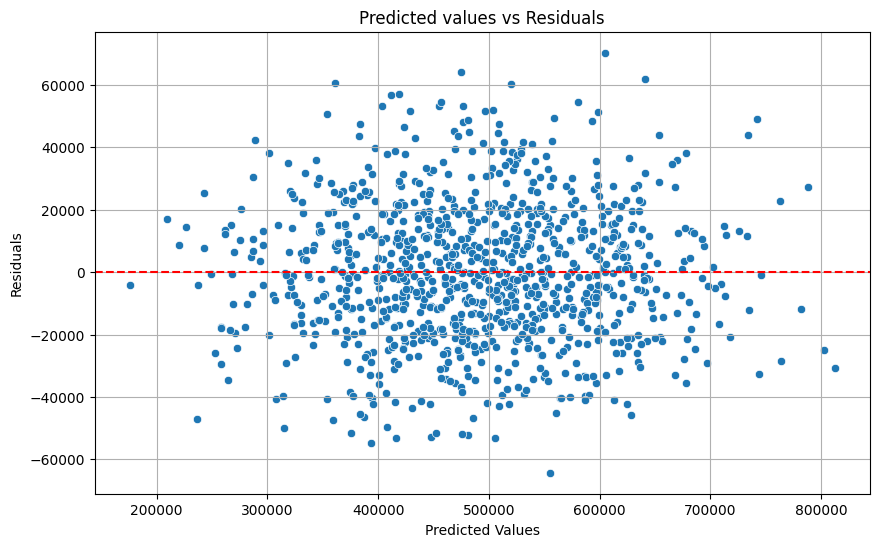

In [43]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=predictions,
    y=residuals
)
plt.axhline(
    y=0,
    linestyle='--',
    color='red'
)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Predicted values vs Residuals")
plt.grid()
plt.show()

The residuals appear reasonably randomly distributed around zero with no clear funnel shape. Therefore, there is no strong visual evidence of heteroscedasticity.

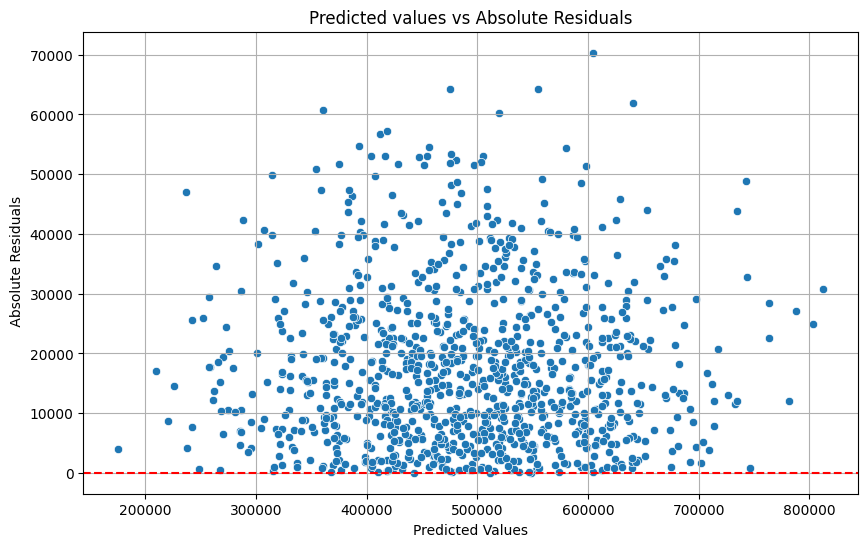

In [44]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=predictions,
    y=np.abs(residuals)
)
plt.axhline(
    y=0,
    linestyle='--',
    color='red'
)
plt.xlabel("Predicted Values")
plt.ylabel(" Absolute Residuals")
plt.title("Predicted values vs Absolute Residuals")
plt.grid()
plt.show()

In [48]:
np.corrcoef(predictions, np.abs(residuals))[0,1]

np.float64(-0.007478483572920742)

From the absolute residuals vs predicted values plot, there is no clear increasing or decreasing trend in the size of residuals across predicted values. The correlation between predicted values and absolute residuals is approximately -0.007, which is very close to zero. This suggests that the error size does not systematically increase or decrease as predicted values change.

Therefore, this plot does not show strong evidence of heteroscedasticity and supports the homoscedasticity assumption.

####  Statistical method: Breusch-Pegan Test

In [49]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# add constant/intercept colum
X_test_scaled_const = sm.add_constant(X_test_scaled)

# Apply Breusch-Pegan test 
bp_test = het_breuschpagan(
    residuals,
    X_test_scaled_const
)

# ctrate readable output
bp_labels = [
    'LM Statistic',
    'LM p-value',
    'F statistic',
    'F p-value'
]
bp_results = dict(zip(bp_labels, bp_test))
bp_results

{'LM Statistic': np.float64(25.648221171015393),
 'LM p-value': np.float64(0.14029293402227513),
 'F statistic': np.float64(1.357731651563615),
 'F p-value': np.float64(0.13926097790202685)}

In [50]:
alpha = 0.05

if bp_results['LM p-value'] < alpha:
    print("Heteroscedasticity is likely present.")
else:
    print("No strong evidence of heteroscedasticity.")

No strong evidence of heteroscedasticity.


### 5.Similar Scales

## Feature Scaling with Z-score standardization


Why Z-Score Standardization: it does two things
- Centers data aorund 0  mean ≈ 0    |    standard deviation ≈ 1
- Makes fearure scale similar

In [7]:
def scaling(X_train, X_test):
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)

    # avoidng division by zero
    std[std == 0] = 1

    X_train_stand = (X_train - mean) /std
    X_test_stand = (X_test - mean) /std

    return X_train_stand, X_test_stand

In [8]:
X_train_scaled, X_test_scaled = scaling(X_train, X_test)

## Linear Regression Training By Different Cost functions

- **Mean Absolute Error**
- **Mean Squared Error**
- **Huber Loss**

In [19]:
class LinearRegression:
    def __init__(
            self, 
            learning_rate=0.01, 
            iterations=100, 
            cost_function='mse', 
            delta=100
        ):
        self.learning_rate=learning_rate
        self.iterations = iterations
        self.cost_function = cost_function
        self.delta = delta
        # training history
        self.mae_scores = []
        self.mse_scores = []
        self.huber_scores = []
        self.rmse_scores = []


    def fit(self, X, y):
        # converting data to numpy array
        X = np.asarray(X, dtype=float)
        # converting target 1D array 
        y = np.asarray(y, dtype=float).ravel()
        # num of data samples, and num of featues
        n_samples, n_features = X.shape

        # initialization of weights and bias
        self.weights = np.zeros(n_features)
        if self.cost_function == 'mae':
            self.bias = np.median(y)
        else:
            self.bias = 0            

        # updating weights and bias in n iterations
        for iterration in range(self.iterations):
            # making predictions 
            y_pred = np.dot(X, self.weights)+self.bias
            # error 
            error = y_pred - y
            # derivatives calculation
            if self.cost_function == 'mse':
                # Mean Squared Error
                dw = (1 / n_samples) * np.dot(X.T, error) 
                db = (1 / n_samples) * np.sum(error)
            elif self.cost_function == 'mae':
                # Mean Absolute Error
                dw = (1 / n_samples) * np.dot(X.T, np.sign(error)) 
                db = (1 / n_samples) * np.sum(np.sign(error))
            elif self.cost_function == 'huber':
                huber_loss = np.where(
                    np.abs(error) <= self.delta,
                    error,
                    self.delta * np.sign(error)
                )
                dw = (1 / n_samples) * np.dot(X.T, huber_loss)
                db = (1 / n_samples) * np.sum(huber_loss)
            else: 
                raise ValueError("Cost function must be 'mse' or 'mae' or 'huber'")

            # updating weights 
            self.weights = self.weights - self.learning_rate * dw 
            self.bias = self.bias - self.learning_rate * db

            # make predictions with updated weights
            y_pred_updated = np.dot(X, self.weights) + self.bias

            # calculate and store MAE
            mae = MeanAbsoluteError(y, y_pred_updated)
            self.mae_scores.append([iterration, mae])

            # calculate and store MSE
            mse = MeanSquaredError(y, y_pred_updated)
            self.mse_scores.append([iterration, mse])

            # calculate and store Huber loss
            huber_loss = HuberLoss(y, y_pred_updated, delta=self.delta)
            self.huber_scores.append([iterration, huber_loss])

            # calculate and store RMSE 
            rmse = RootMeanSquaredError(y, y_pred_updated)
            self.rmse_scores.append([iterration, rmse])
                
      
    def predict(self, X_new):
        return np.dot(X_new, self.weights) + self.bias


### Mean Absolute Error 

Mean Absolute Error calculates the average absolute difference between the actual and predicted values.                                                         
Formula: **MAE = (1 / n) * Σ |yᵢ - ŷ|**
When to use: 
- 1. When data contains real extreme values and outliers 
- 2. When target distribution is skewed 

In [11]:
linear_mae_model = LinearRegression(
    learning_rate=100,
    iterations=6000,
    cost_function='mae'
)

In [12]:
linear_mae_model.fit(X_train_scaled, y_train)

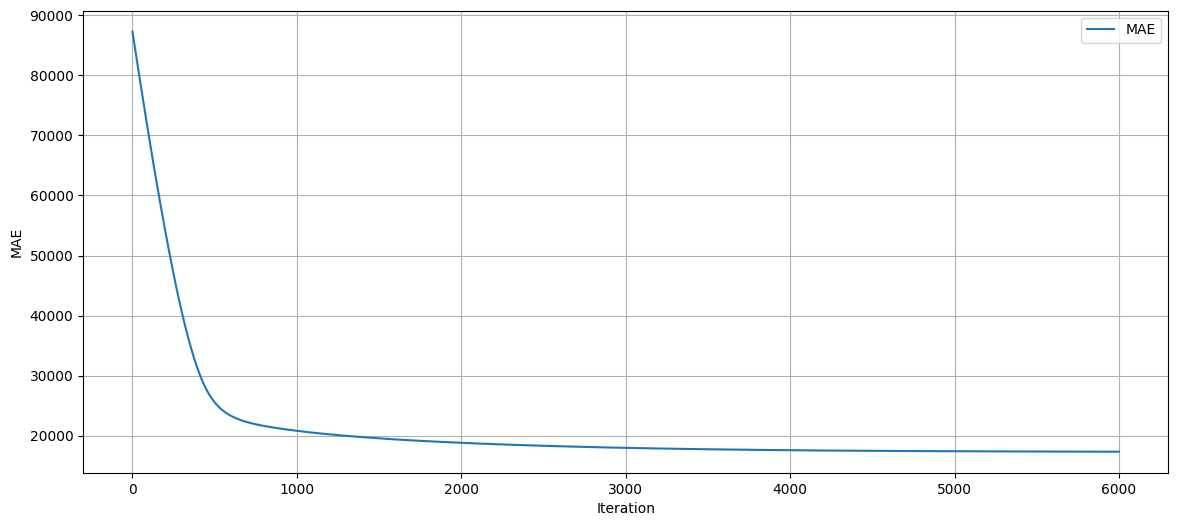

In [13]:
iterations = [item[0] for item in linear_mae_model.mae_scores]
mae_costs = [item[1] for item in linear_mae_model.mae_scores]

plt.figure(figsize=(14, 6))
plt.plot(iterations, mae_costs, label='MAE')
plt.xlabel('Iteration')
plt.ylabel('MAE')
plt.legend()
plt.grid()
plt.show()

When `Linear Regression` Model trained with `Mean Absolute Error` cost function, bigger learning rate and more iterations than `MSE` are required to converge. The reason is MAE's subgradient is much smaller than the `MSE` gradient scale. For example: if error is 50,000 in `MSE`, its gradient contribution contains 50,000 dw = (1 / n_samples) * np.dot(X.T, error). But in `MAE` the magnitude disappears. dw = (1 / n_samples) * np.dot(X.T,np.sign(error))                                                   
error =      10  → sign =  1                                                                                                                                            
error =   1,000  → sign =  1                                                                                                                                            
error =  50,000  → sign =  1                                                                                                                                            
error = 500,000  → sign =  1  
A simple comparsion: x = 0.8 error = 50,000                                                                                                                                      
- in `MSE` x * error = 0.8 * 50,000 = 40,000 ->  MSE gradient contribution:  40,000                     
- in `MAE` x * sign(error) = 0.8 * 1 = 0.8 -> MAE gradient contribution:       0.8    

In [16]:
mae_model_train_predictions = linear_mae_model.predict(X_train_scaled)
mae_model_test_predictions = linear_mae_model.predict(X_test_scaled)

In [17]:
mae_model_train_mae = MeanAbsoluteError(y_train, mae_model_train_predictions)
mae_model_test_mae = MeanAbsoluteError(y_test, mae_model_test_predictions)
print(f"Mean Absolute Error cost function Model Mean Absolute Error Performance on train set {mae_model_train_mae}")
print(f"Mean Absolute Error cost function Model Mean Absolute Error Performance on test set {mae_model_test_mae}")

Mean Absolute Error cost function Model Mean Absolute Error Performance on train set 17326.899266787033
Mean Absolute Error cost function Model Mean Absolute Error Performance on test set 18025.467969996447


In [18]:
mae_model_train_mse = MeanSquaredError(y_train, mae_model_train_predictions)
mae_model_test_mse = MeanSquaredError(y_test, mae_model_test_predictions)
print(f"Mean Absolute Error cost function Model Mean Squared Error Performance on train set {mae_model_train_mse}")
print(f"Mean Absolute Error cost function Model Mean Squared Error Performance on test set {mae_model_test_mse}")

Mean Absolute Error cost function Model Mean Squared Error Performance on train set 472022930.18335277
Mean Absolute Error cost function Model Mean Squared Error Performance on test set 507951629.48844063


In [19]:
mae_model_train_rmse = RootMeanSquaredError(y_train, mae_model_train_predictions)
mae_model_test_rmse = RootMeanSquaredError(y_test, mae_model_test_predictions)
print(f"Mean Absolute Error cost function Model Root Mean Squared Error Performance on train set {mae_model_train_rmse}")
print(f"Mean Absolute Error cost function Model Root Mean Squared Error Performance on test set {mae_model_test_rmse}")

Mean Absolute Error cost function Model Root Mean Squared Error Performance on train set 21726.088699610722
Mean Absolute Error cost function Model Root Mean Squared Error Performance on test set 22537.782266417445


In [20]:
mae_model_train_r2score = R2Score(y_train, mae_model_train_predictions)
mae_model_test_2score = R2Score(y_test, mae_model_test_predictions)
print(f"Mean Absolute Error cost function Model R2 Score Performance on train set {mae_model_train_r2score}")
print(f"Mean Absolute Error cost function Model R2 Score Performance on test set {mae_model_test_2score}")

Mean Absolute Error cost function Model R2 Score Performance on train set 0.9601742169837013
Mean Absolute Error cost function Model R2 Score Performance on test set 0.9581598422841463


### Training with Mean Squared Error

In [11]:
linear_mse_model = LinearRegression(
    learning_rate=0.01,
    iterations=1000,
    cost_function='mse'
)

In [12]:
linear_mse_model.fit(X_train_scaled, y_train)

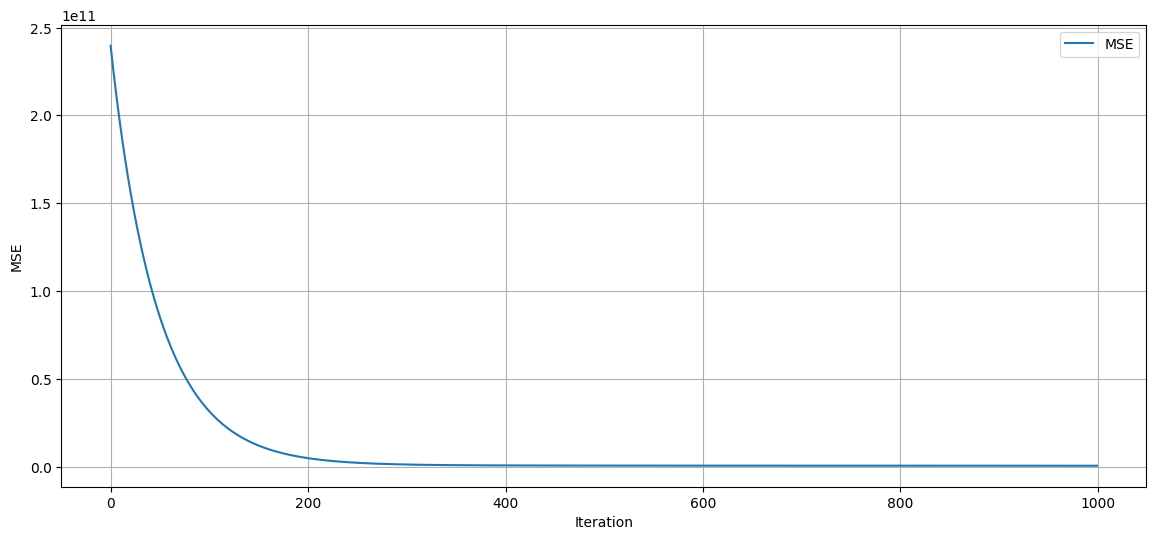

In [13]:
iterations = [item[0] for item in linear_mse_model.mse_scores]
mae_costs = [item[1] for item in linear_mse_model.mse_scores]

plt.figure(figsize=(14, 6))
plt.plot(iterations, mae_costs, label='MSE')
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.legend()
plt.grid()
plt.show()

unlike Linear Regression training with `MAE`, Training Linear Regression with `MSE` required lesser iterations and smaller learning rate to converge.

In [14]:
mse_model_train_predictions = linear_mse_model.predict(X_train_scaled)
mse_model_test_predictions = linear_mse_model.predict(X_test_scaled)

In [15]:
mse_model_mae_train = MeanAbsoluteError(y_train, mse_model_train_predictions)
mse_model_mae_test = MeanAbsoluteError(y_test, mse_model_test_predictions)

print(f"Linear Regression model trained with MSE Mean Absolute Error on Train set: {mse_model_mae_train}")
print(f"Linear Regression model trained with MSE Mean Absolute Error on Test set: {mse_model_mae_test}")

Linear Regression model trained with MSE Mean Absolute Error on Train set: 17990.538002915167
Linear Regression model trained with MSE Mean Absolute Error on Test set: 17811.076320230495


In [16]:
mse_model_mse_train = MeanSquaredError(y_train, mse_model_train_predictions)
mse_model_mse_test = MeanSquaredError(y_test, mse_model_test_predictions)

print(f"Linear Regression model trained with MSE Mean Squared Error on Train set: {mse_model_mse_train}")
print(f"Linear Regression model trained with MSE Mean Squared Error on Test set: {mse_model_mse_test}")

Linear Regression model trained with MSE Mean Squared Error on Train set: 505890110.80617416
Linear Regression model trained with MSE Mean Squared Error on Test set: 492907136.21376854


In [17]:
mse_model_rmse_train = RootMeanSquaredError(y_train, mse_model_train_predictions)
mse_model_rmse_test = RootMeanSquaredError(y_test, mse_model_test_predictions)

print(f"Linear Regression model trained with MSE Root Mean Squared Error on Train set: {mse_model_rmse_train}")
print(f"Linear Regression model trained with MSE Root Mean Squared Error on Test set: {mse_model_rmse_test}")

Linear Regression model trained with MSE Root Mean Squared Error on Train set: 22492.001040507137
Linear Regression model trained with MSE Root Mean Squared Error on Test set: 22201.51202539522


In [18]:
mse_model_r2score_trarin = R2Score(y_train, mse_model_train_predictions)
mse_model_r2score_test = R2Score(y_test, mse_model_test_predictions)

print(f"Linear Regression model trained with MSE R2 score on Train set: {mse_model_r2score_trarin}")
print(f"Linear Regression model trained with MSE R2 score on Test set: {mse_model_r2score_test}")

Linear Regression model trained with MSE R2 score on Train set: 0.9575359290233594
Linear Regression model trained with MSE R2 score on Test set: 0.9586761255601683


### Training with Huber Loss

one important decision in training with Huber loss is to choose value for `delta`
When error is bigger than delta, huber cost function applies `MSE` otherwise `MAE`
I am going to choose the value delta by making predictions by the the linear model( trained with MSE cost function) and calculate residualts. Based on residuals scale I will choose the value

In [23]:
mse_trained_model_train_predictions = linear_mse_model.predict(X_train_scaled)
residuals_df = pd.DataFrame({
    "Actual Values":y_train,
    "Predicted_values":mse_trained_model_train_predictions,
    "residuals":(round(abs(y_train-mse_trained_model_train_predictions)))
})
residuals_df['residuals'].describe()

count     4000.000000
mean     17990.535000
std      13500.969921
min          3.000000
25%       7285.000000
50%      15301.000000
75%      25923.250000
max      79059.000000
Name: residuals, dtype: float64

In [24]:
delta_values = [
    7000,
    10000,
    15000,
    20000,
    26000,
    35000
]
results = []

for delta in delta_values:
    linear_huber_model = LinearRegression(
        learning_rate=1,
        iterations=10000,
        cost_function='huber',
        delta=delta
    )
    linear_huber_model.fit(X_train_scaled, y_train)
    test_predictions = linear_huber_model.predict(X_test_scaled)
    mae = MeanAbsoluteError(y_test, test_predictions)
    rmse = RootMeanSquaredError(y_test, test_predictions)
    results.append({
        "delta":delta,
        "mae":mae,
        "rmse":rmse
    })

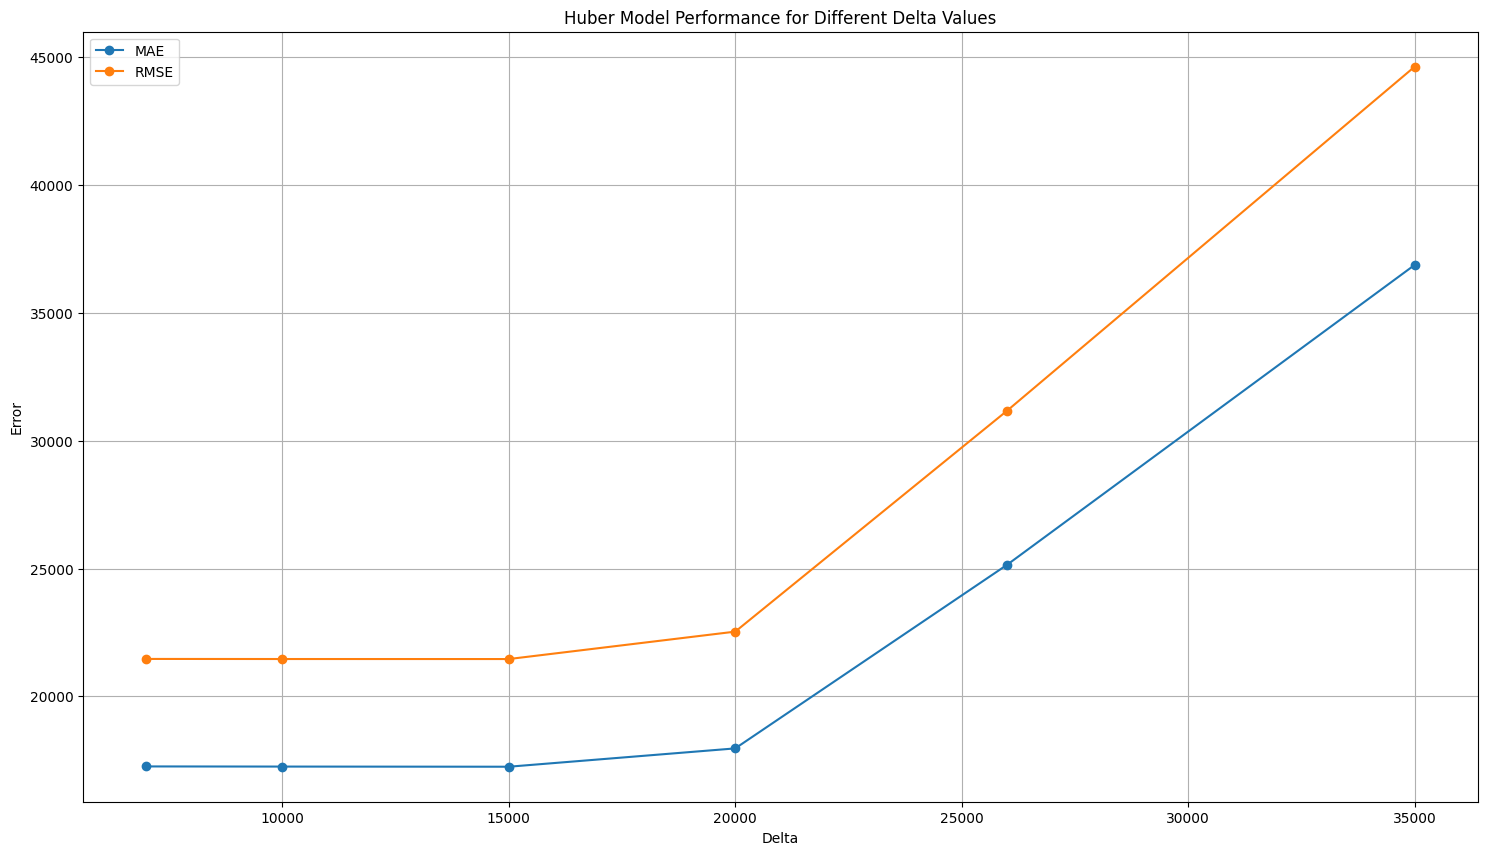

In [30]:
results_df = pd.DataFrame(results)
plt.figure(figsize=(18, 10))
plt.plot(
    results_df['delta'],
    results_df['mae'],
    marker='o',
    label='MAE'
)

plt.plot(
    results_df['delta'],
    results_df['rmse'],
    marker='o',
    label='RMSE'
)

plt.xlabel('Delta')
plt.ylabel('Error')
plt.title('Huber Model Performance for Different Delta Values')
plt.legend()
plt.grid()

plt.show()

here, the plots shows that `15000` is the best value for delta, but in delta is equal 20000 or more the error has been increasing significatly, but this is a bit confusing. Because when delta>= 20 000, huber loss applies `MSE` for most errors, in that case not required bigger learning rate (like used 1) and more iterations (used 1000).For this reason the error has been significatly big. 

In [47]:
residuals_df['residuals'].describe()

count     4000.000000
mean     17990.535000
std      13500.969921
min          3.000000
25%       7285.000000
50%      15301.000000
75%      25923.250000
max      79059.000000
Name: residuals, dtype: float64

here in residuals values describe , we can see 25% residuals <= 7285, and 50% <= 15301. I take these two values as candidates

In [54]:
linear_huber_model = LinearRegression(
    learning_rate=0.1,
    iterations=1000,
    cost_function='huber',
    delta=7285
)

In [55]:
linear_huber_model.fit(X_train_scaled, y_train)

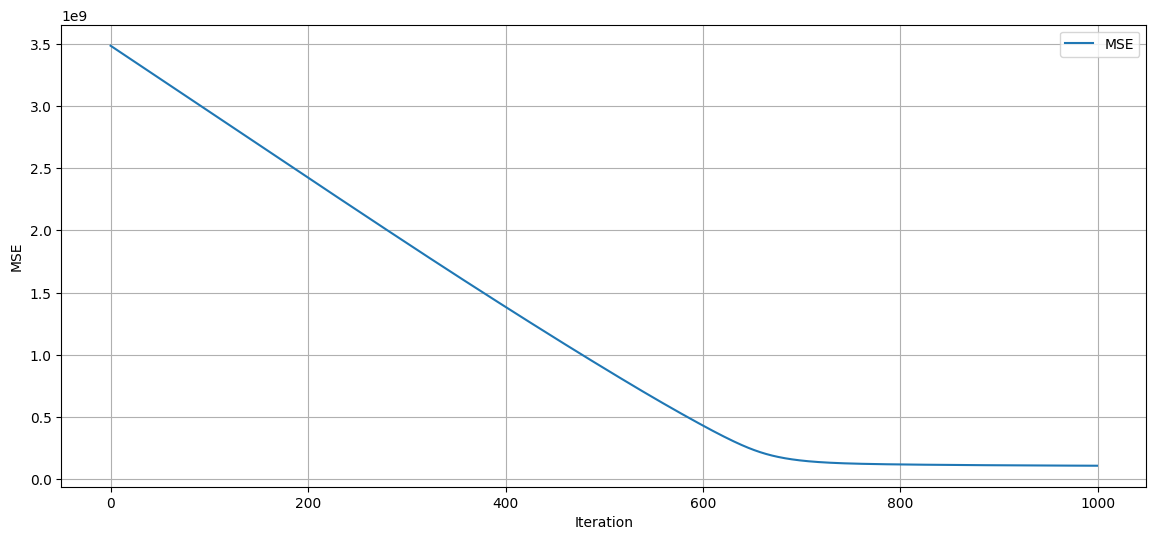

In [56]:
iterations = [item[0] for item in linear_huber_model.huber_scores]
mae_costs = [item[1] for item in linear_huber_model.huber_scores]

plt.figure(figsize=(14, 6))
plt.plot(iterations, mae_costs, label='MSE')
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.legend()
plt.grid()
plt.show()

In [57]:
huber_model_train_predictions = linear_huber_model.predict(X_train_scaled)
huber_model_test_predictions = linear_huber_model.predict(X_test_scaled)

In [58]:
huber_model_mae_train = MeanAbsoluteError(y_train, huber_model_train_predictions)
huber_model_mae_test = MeanAbsoluteError(y_test, huber_model_test_predictions)

print(f"Linear Regression model trained with Huber loss (delta=7285) Mean Absolute Error on Train set: {huber_model_mae_train}")
print(f"Linear Regression model trained with Huber loss (delta=7285) Mean Absolute Error on Test set: {huber_model_mae_test}")


Linear Regression model trained with Huber loss (delta=7285) Mean Absolute Error on Train set: 18112.769326404752
Linear Regression model trained with Huber loss (delta=7285) Mean Absolute Error on Test set: 17929.667568199202


In [59]:
huber_model_mse_train = MeanSquaredError(y_train, huber_model_train_predictions)
huber_model_mse_test = MeanSquaredError(y_test, huber_model_test_predictions)

print(f"Linear Regression model trained with Huber loss (delta=7285) Mean Squared Error on Train set: {huber_model_mse_train}")
print(f"Linear Regression model trained with Huber loss (delta=7285) Mean Squared Error on Test set: {huber_model_mse_test}")

Linear Regression model trained with Huber loss (delta=7285) Mean Squared Error on Train set: 514214693.43316954
Linear Regression model trained with Huber loss (delta=7285) Mean Squared Error on Test set: 500152949.99213016


In [60]:
huber_model_rmse_train = RootMeanSquaredError(y_train, huber_model_train_predictions)
huber_model_rmse_test = RootMeanSquaredError(y_test, huber_model_test_predictions)

print(f"Linear Regression model trained with Huber loss (delta=7285) Root Mean Squared Error on Train set: {huber_model_rmse_train}")
print(f"Linear Regression model trained with Huber loss (delta=7285) Root Mean Squared Error on Test set: {huber_model_rmse_test}")

Linear Regression model trained with Huber loss (delta=7285) Root Mean Squared Error on Train set: 22676.302463875578
Linear Regression model trained with Huber loss (delta=7285) Root Mean Squared Error on Test set: 22364.099579283986


## Linear Regression Training Methods 

- **Batch Gradient Descent**
- **Stochastic Gradient Descent**
- **Mini-Batch Gradient Descent**

In [ ]:
class LinearRegression:
    def __init__(self, learning_rate=0.01, iterations=100, method='batch', cost_function='mse', batch_size=32):
        self.learning_rate=learning_rate
        self.iterations = iterations
        self.method = method
        self.cost_function = cost_function
        self.batch_size = batch_size
        self.rmse_costs = []


    def fit(self, X, y):
        # converting data to numpy array
        X = np.array(X, dtype=float)
        # converting target 1D array 
        y = np.array(y, dtype=float).ravel()
        # num of data samples, and num of featues
        n_samples, n_features = X.shape

        # initialization of weights and bias
        self.weights = np.zeros(n_features)
        self.bias = 0

        # updating weights and bias in n iterations
        for iter in range(self.iterations):
            # if method Batch Gradient Descent 
            if self.method ==  'batch':
                # making predictions 
                y_pred = np.dot(X, self.weights)+self.bias
                # error 
                error = y_pred - y
                # derivatives calculation
                if self.cost_function == 'mse':
                    # Mean Squared Error
                    dw = (1 / n_samples) * np.dot(X.T, error) 
                    db = (1 / n_samples) * np.sum(error)
                elif self.cost_function == 'mae':
                    # Mean Absolute Error
                    dw = (1 / n_samples) * np.dot(X.T, np.sign(error)) 
                    db = (1 / n_samples) * np.sum(np.sign(error))
                else:
                    raise ValueError("Cost function must be either 'mse' or 'mae'")

                # updating weights 
                self.weights = self.weights - self.learning_rate * dw 
                self.bias = self.bias - self.learning_rate * db

                # storing rmse cost to list
                rmse = RootMeanSquaredError(y, y_pred)
                self.rmse_costs.append([iter,rmse ])

            # if method Stocastic Gradient Descent
            elif self.method == 'sgd': 
                indices = np.random.permutation(n_samples)

                for i in indices:
                    # extracting a random sample/row from data
                    X_i = X[i]
                    y_i = y[i]
                    # making prediction
                    y_pred = np.dot(X_i, self.weights)+self.bias
                    # calculating error
                    error = y_pred - y_i
                    # calculating derivatives
                    if self.cost_function == 'mse':
                        # Mean Squared Error
                        dw = X_i * error
                        db = np.sum(error)
                    elif self.cost_function == 'mae':
                        # Mean Absolute Error
                        dw = X_i * np.sign(error)
                        db = np.sum(np.sign(error))
                    else:
                        raise ValueError("Cost function must be either 'mse' or 'mae'")
                    # updating weights
                    self.weights = self.weights - self.learning_rate * dw
                    self.bias = self.bias - self.learning_rate * db 

                # storing error to list in each iteration
                y_pred_all = np.dot(X, self.weights) + self.bias
                error_all = y_pred_all - y 
                rmse = RootMeanSquaredError(y, error_all)
                self.rmse_costs.append([iter, rmse])


            # if method is mini-batch Gradient Descent
            elif self.method == 'mini_batch':
                indices = np.random.permutation(n_samples)

                # shuffling data
                X_shuflled = X[indices]
                y_shuflled = y[indices]

                for star in range(0, n_samples, self.batch_size):
                    # extracting batch-data samples
                    end = star + self.batch_size
                    X_batch = X_shuflled[star:end]
                    y_batch = y_shuflled[star:end]
                    n_batch = len(X_batch)
                    # making predictions 
                    y_pred = np.dot(X_batch, self.weights)+self.bias
                    # calculating error
                    error = y_pred - y_batch
                    # calculating derivaties
                    if self.cost_function == 'mse':
                        # Mean Squared Error
                        dw = (1 / n_batch) * np.dot(X_batch.T, error)
                        db = (1 / n_batch) * np.sum(error)
                    elif self.cost_function == 'mae':
                        # strong error to list
                        cost = np.mean(np.abs(error))
                        self.costs.append([iter, cost])
                        # Mean Absolute Error
                        dw = (1 / n_batch) * np.dot(X_batch.T, np.sign(error))
                        db = (1 / n_batch) * np.sum(np.sign(error))
                    else:
                        raise ValueError("Cost function must be either 'mse' or 'mae'")
                    # updating weights 
                    self.weights = self.weights - self.learning_rate * dw
                    self.bias = self.bias - self.learning_rate * db
                
                #stroring cost
                y_pred_all = np.dot(X, self.weights)+self.bias
                error_all = y_pred_all - y
                rmse = RootMeanSquaredError(y, error_all)
                self.rmse_costs.append([iter, rmse])

            else:
                raise ValueError("method must be one of them 'batch', 'sgd', 'mini_batch'")
        
    def predict(self, X_new):
        return np.dot(X_new, self.weights) + self.bias


### Linear Regression Batch Training

In [10]:
linearRegression = LinearRegression(
    learning_rate=1e-2,
    iterations=400,
    method='batch'
)

In [11]:
linearRegression.fit(X_train_stand, y_train)

#### **Plotting model learning Curve**

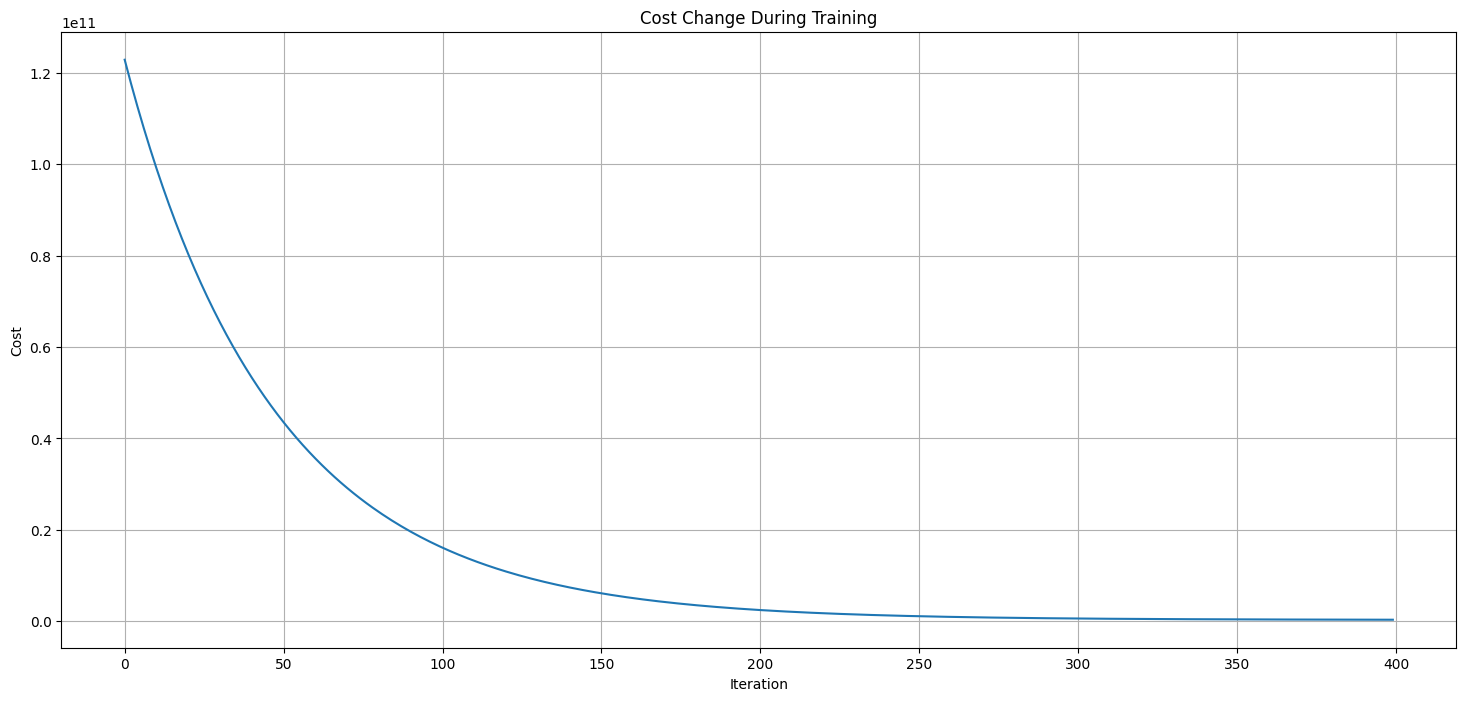

In [12]:
iterations = [item[0] for item in linearRegression.costs]
cost_values = [item[1] for item in linearRegression.costs]

plt.figure(figsize=(18, 8))
plt.plot(iterations, cost_values)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost Change During Training")
plt.grid()
plt.show()

From the model cost function plot, we can understand cost decreased smoothly, it means, learning_rate is good.
Model learnt fast in early iterations(from 1 to 150), after around 250-300 iterations, the curve become almost flat. So no need 400 iterations. 300 is acceptable.

#### **Validating the Linear Model trained with batch method**

In [13]:
train_predictions = linearRegression.predict(X_train_stand)
test_predictions = linearRegression.predict(X_test_stand)

In [14]:
mse_train = MeanSquaredError(y_train, train_predictions)
mae_train = MeanAbsoluteError(y_train, train_predictions)
rmse_train = RootMeanSquaredError(y_train, train_predictions)

mse_test = MeanSquaredError(y_test, test_predictions)
mae_test = MeanAbsoluteError(y_test, test_predictions)
rmse_test = RootMeanSquaredError(y_test, test_predictions)

print("Training Performace Metrics:")
print("Training set Mean Squared Error (MSE):", mse_train)
print("Training set Mean Absolute Error (MAE):", mae_train)
print("Training set Root Mean Squared Error (RMSE):", rmse_train)

print("---------------------------------------------")
print("Testing Performace Metrics:")
print("Test set Mean Squared Error (MSE):", mse_test)
print("Test set Mean Absolute Error (MAE):", mae_test)
print("Test set Root Mean Squared Error (RMSE):", rmse_test)

Training Performace Metrics:
Training set Mean Squared Error (MSE): 682417459.1404963
Training set Mean Absolute Error (MAE): 20913.64525438665
Training set Root Mean Squared Error (RMSE): 26123.121160008737
---------------------------------------------
Testing Performace Metrics:
Test set Mean Squared Error (MSE): 639564136.6824183
Test set Mean Absolute Error (MAE): 20231.884923359874
Test set Root Mean Squared Error (RMSE): 25289.60530894894


Mean Absolute Error is very similiar in training and test set. On Average model is wrong about 20.913 USD. 
Root Mean Squared Error is also very similiar on both training and test sets. The model's typical error is around 26,284 USD, with larger mistakes punished more strongly.
So since there is no big difference between MAE, RMSE in train and test sets, it is `well generalized` model, nor signs for `High Bias` or `Underfitting`  and `High Variance` or `Overfitting`


#### **R2 Score**

In [15]:
r2score_train = R2Score(y_train, train_predictions)
r2score_test = R2Score(y_test, test_predictions)

print("---------------------------------------------")
print("R² Score:")
print("Training set R² Score:", r2score_train)
print("Test set R² Score:", r2score_test)


---------------------------------------------
R² Score:
Training set R² Score: 0.9425616319974951
Test set R² Score: 0.94690055769217


Model explains about 94% of the variation in apartement prices. THis also supports `Well generalized` model

#### **checking Residuals**

In [16]:
residuals = np.array(y_test) - test_predictions

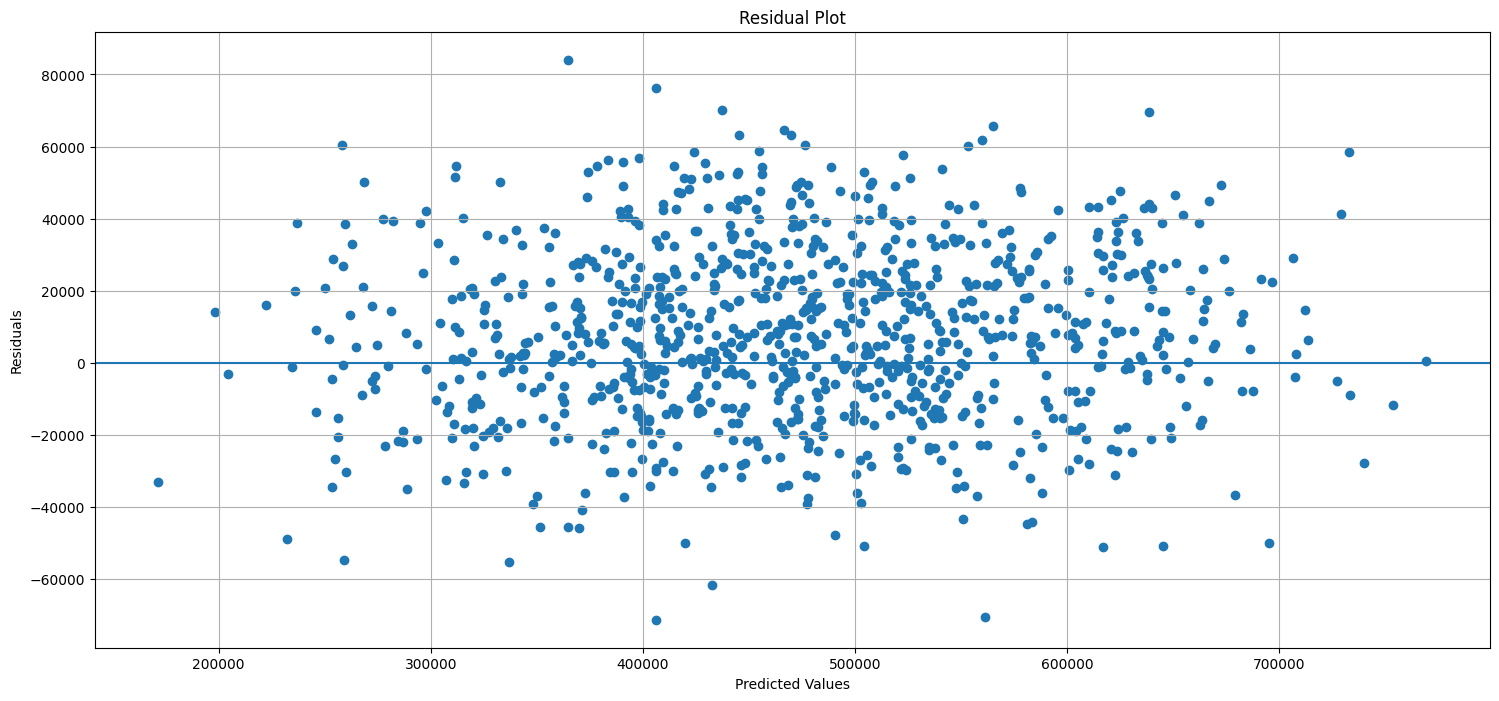

In [17]:
# 1. Residual plot
plt.figure(figsize=(18, 8))
plt.scatter(test_predictions, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid()
plt.show()


The Linear model is reasonable. The model is not missing a very obvious nonlinear pattern. But there are some large residuals around -80,000 to +80,000. That measn some apartment are stull hard to predict. possible reasons: luxury apartments, location effect, outliers, missing important features, special apartment conditions

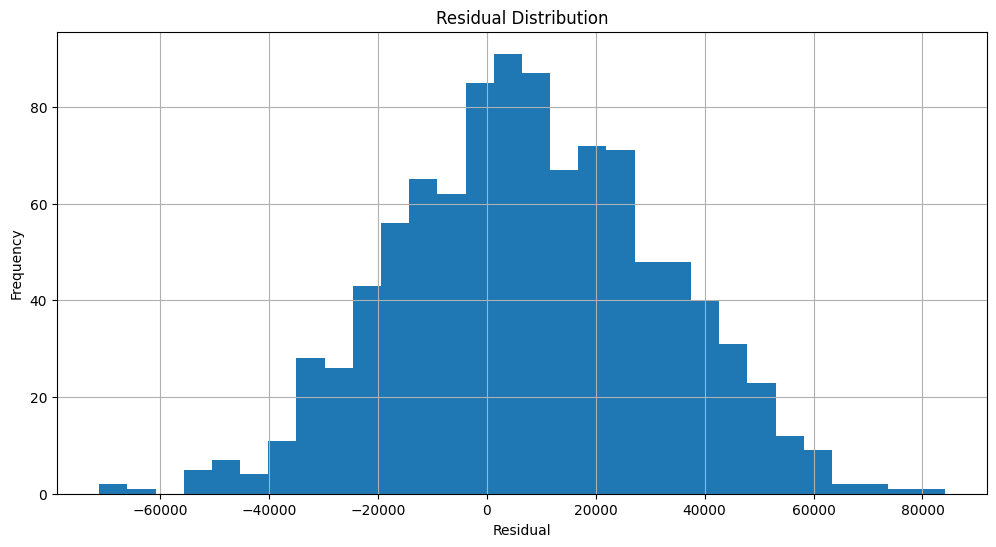

In [18]:
# 2. Residual histogram
plt.figure(figsize=(12, 6))
plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.grid()
plt.show()

Rediual histogram also supports models performance well. Values are mostly centered around 0. That means the model is not strongly biased toward only overpredicting or only underpredicting. But center seems slightly more on the positive side. it means the model sloghtly underpredicts some apartments.

#### **Comparing predicted vs actual values**

In [19]:
resutls = pd.DataFrame({
    "Actual_test_data_value": y_test,
    "Predited_value_test_data": np.round(test_predictions, 2),
    "Diffeerence": np.round(np.array(y_test) - test_predictions, 2)
})

resutls

,Actual_test_data_value,Predited_value_test_data,Diffeerence
4302,559992.83,545954.79,14038.04
3637,326112.81,342688.25,-16575.44
4083,548976.66,535404.24,13572.42
612,402845.07,398135.67,4709.40
4105,627713.21,592492.87,35220.34
...,...,...,...
893,510783.42,470780.82,40002.60
1991,427155.92,374111.84,53044.08
909,425369.42,442128.99,-16759.57
939,530174.84,530864.51,-689.67


### Linear Regression Stocastic Gradient Descent Training

In [20]:
linear_sgd = LinearRegression(
    learning_rate=1e-5,
    iterations=100,
    method='sgd'
)

In [21]:
linear_sgd.fit(X_train_stand, y_train)

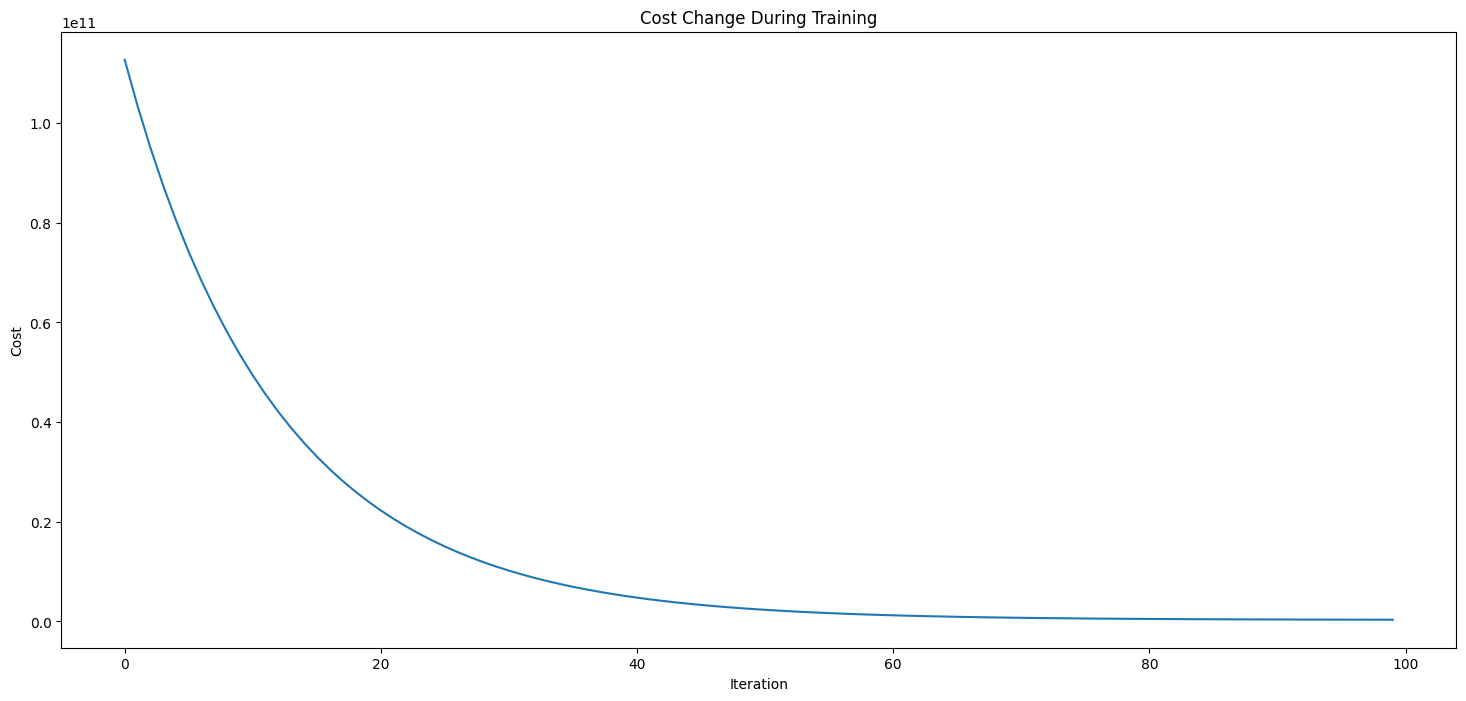

In [22]:
iterations = [item[0] for item in linear_sgd.costs]
cost_values = [item[1] for item in linear_sgd.costs]

plt.figure(figsize=(18, 8))
plt.plot(iterations, cost_values)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost Change During Training")
plt.show()

from the learning curve, we can understand const has been descreased smoothsly, it has been flat in 80-100 iterations


#### Validating Linear Model Trained with Stocastic Gradient Descent approach

In [23]:
train_predictions_sgd = linear_sgd.predict(X_train_stand)
test_predictions_sgd = linear_sgd.predict(X_test_stand)

In [24]:
mae_train = MeanAbsoluteError(y_train, train_predictions_sgd)
mse_train = MeanSquaredError(y_train, train_predictions_sgd)
rmse_train = RootMeanSquaredError(y_train, train_predictions_sgd)

mae_test = MeanAbsoluteError(y_test, test_predictions_sgd)
mse_test = MeanSquaredError(y_test, test_predictions_sgd)
rmae_test = RootMeanSquaredError(y_test, test_predictions_sgd)

print("Model Performance Metics")
print("Model performance on Training Data")
print(f"Mean Absolute Error: {mae_train}")
print(f"Mean Squared Error: {mse_train}")
print(f"Root Mean Squared Error: {rmse_train}")
print("---------------------------------")
print("Model Performance on Test data ")
print(f"Mean Absolute Error: {mae_test}")
print(f"Mean Squared Error: {mse_test}")
print(f"Root Mean Squared Error: {rmse_test}")

Model Performance Metics
Model performance on Training Data
Mean Absolute Error: 20963.977383589336
Mean Squared Error: 685571909.0889019
Root Mean Squared Error: 26183.42813859373
---------------------------------
Model Performance on Test data 
Mean Absolute Error: 20277.784205252094
Mean Squared Error: 642446261.3630106
Root Mean Squared Error: 25289.60530894894


Model performs well in both train and test sets, there is no big difference in error rates in both datasets. So we can say it is well generalized model. No signs for overfitting or underfitting

#### R2Score

In [25]:
sgd_model_r2score_train = R2Score(y_train, train_predictions_sgd)
sgd_model_r2score_test = R2Score(y_test, test_predictions_sgd)

print(f"Model'2 R2 Score on Train data {sgd_model_r2score_train}")
print(f"Model'2 R2 Score on Test data {sgd_model_r2score_test}")

Model'2 R2 Score on Train data 0.9422961252251298
Model'2 R2 Score on Test data 0.9466612709585597


Model's predictions are strong, way more better than baseline model, model explains about 94% variations of apartments prices very well.

#### Residuals checking

In [26]:
sgd_model_residuals_test = np.array(y_test) - test_predictions_sgd

print("Mean Residual: ", np.mean(sgd_model_residuals_test))

Mean Residual:  8087.122627323607


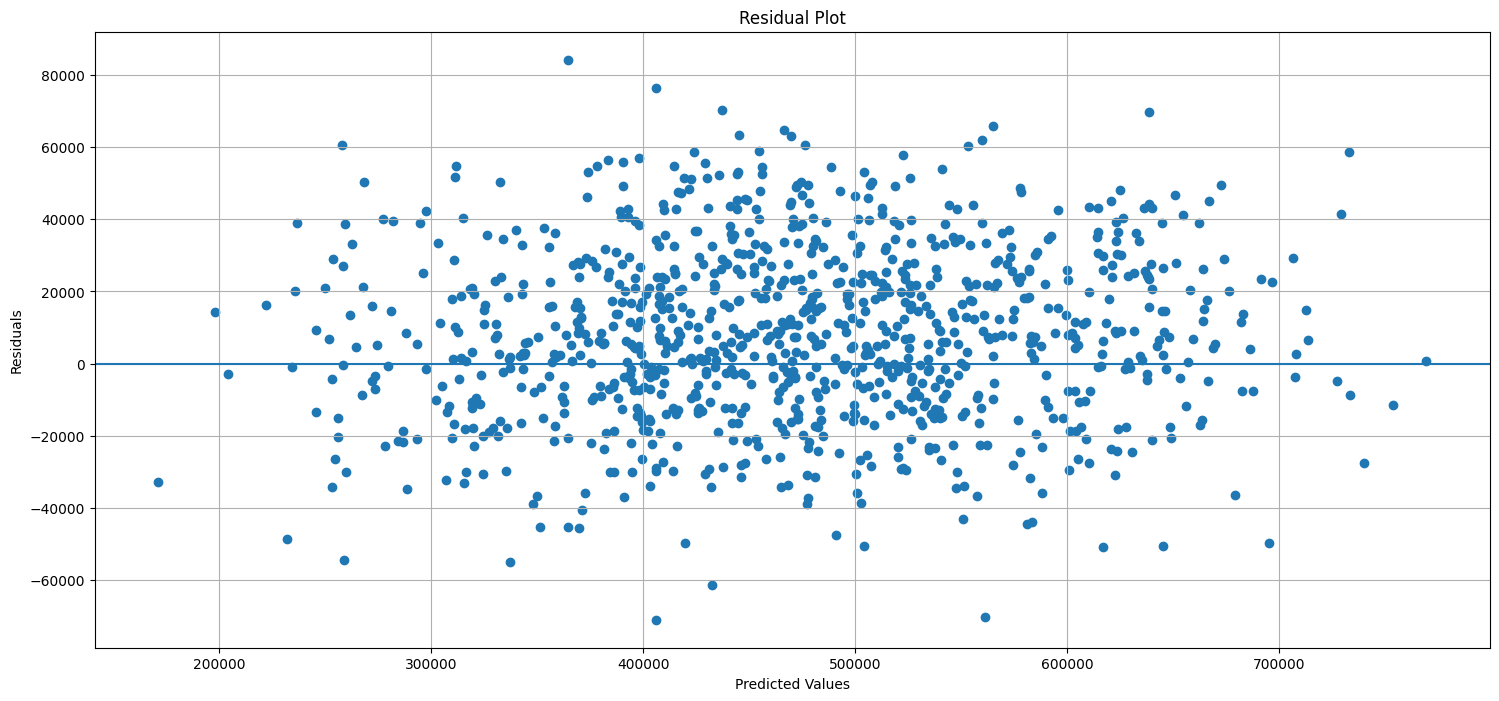

In [27]:
# 1. Residual plot
plt.figure(figsize=(18, 8))
plt.scatter(test_predictions_sgd, sgd_model_residuals_test)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid()
plt.show()


from this plot We can understand that model errors are random, model captured the main relationship

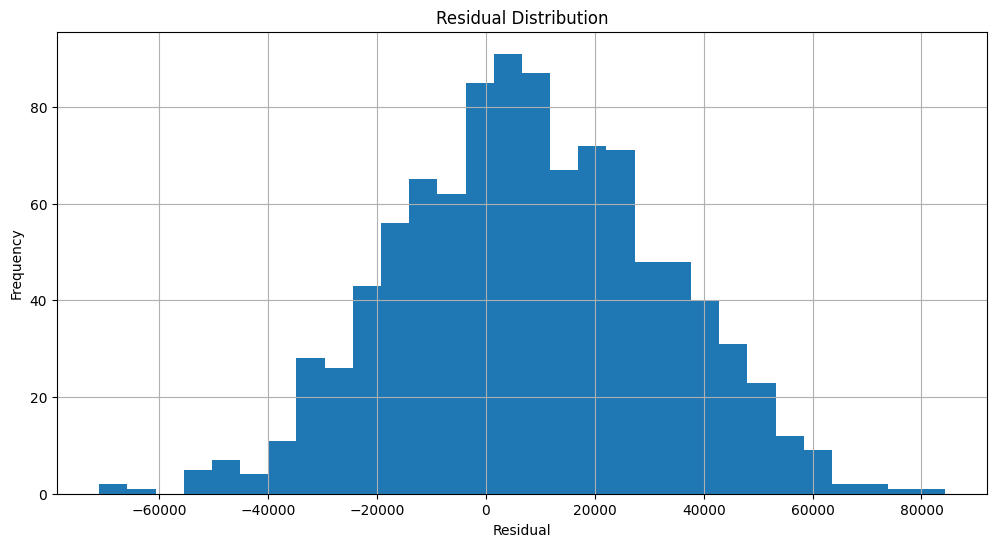

In [28]:
# 2. Residual histogram
plt.figure(figsize=(12, 6))
plt.hist(sgd_model_residuals_test, bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.grid()
plt.show()

THis plot tells us about model "Most errors are small, large errors are rare. Model is balanced

In [29]:
resutls_sgd = pd.DataFrame({
    "Actual_test_data_value": y_test,
    "Predited_value_test_data": np.round(test_predictions_sgd, 2),
    "Diffeerence": np.round(np.array(y_test) - test_predictions_sgd, 2)
})

resutls_sgd

,Actual_test_data_value,Predited_value_test_data,Diffeerence
4302,559992.83,545783.79,14209.04
3637,326112.81,342515.65,-16402.84
4083,548976.66,535240.32,13736.34
612,402845.07,397964.00,4881.07
4105,627713.21,592307.24,35405.97
...,...,...,...
893,510783.42,470597.56,40185.86
1991,427155.92,373951.00,53204.92
909,425369.42,441965.70,-16596.28
939,530174.84,530702.95,-528.11


### Linear Regression Mini-batch Gradient Training

In [30]:
linear_mini_batch = LinearRegression(
    learning_rate=1e-4,
    iterations=300,
    method='mini_batch',
    batch_size=32
)

In [31]:
linear_mini_batch.fit(X_train_stand, y_train)

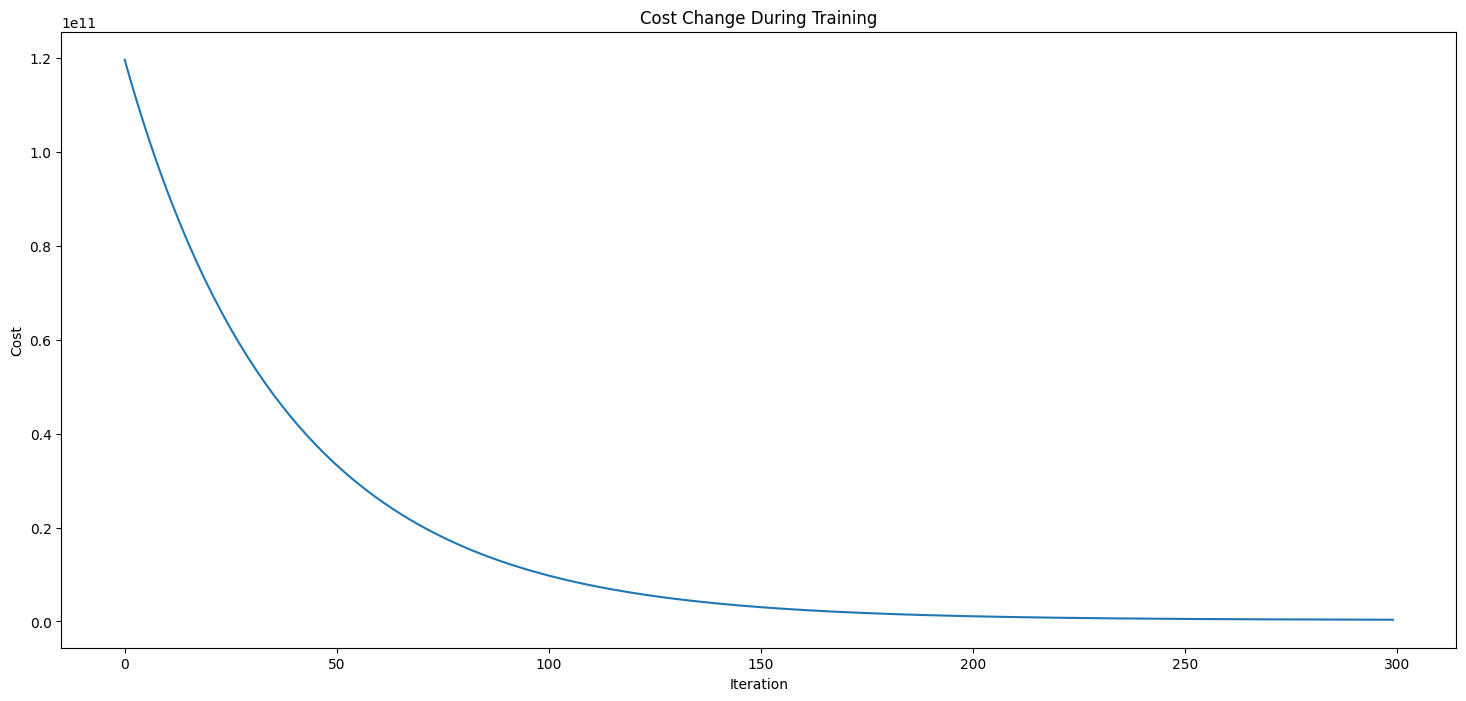

In [32]:
iterations = [item[0] for item in linear_mini_batch.costs]
cost_values = [item[1] for item in linear_mini_batch.costs]

plt.figure(figsize=(18, 8))
plt.plot(iterations, cost_values)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost Change During Training")
plt.show()

Cost has been decreased smoothsly, it has been flat in 250-300 iterations

#### Evaluating Linear Model Trained with Mini-Batch Gradient Descent 

In [33]:
train_predictions_mini_batch = linear_mini_batch.predict(X_train_stand)
test_predictions_mini_batch = linear_mini_batch.predict(X_test_stand)

In [34]:
mini_batch_model_mae_train = MeanAbsoluteError(y_train, train_predictions_mini_batch)
mini_batch_model_mse_train = MeanSquaredError(y_train, train_predictions_mini_batch)
mini_batch_model_rmse_train = RootMeanSquaredError(y_train, train_predictions_mini_batch)

mini_batch_model_mae_test = MeanAbsoluteError(y_test, test_predictions_mini_batch)
mini_batch_model_mse_test = MeanSquaredError(y_test, test_predictions_mini_batch)
mini_batch_model_rmse_test = RootMeanSquaredError(y_test, test_predictions_mini_batch)


print("Mini-Batch Gradient Descent Model Perforamnce:")
print("On Train Data")
print("Mean Absolute Error", mini_batch_model_mae_train)
print("Mean Squared Error", mini_batch_model_mse_train)
print("Root Mean Squared Error", mini_batch_model_rmse_train)
print("---------------------------------")
print("On Test data")
print("Mean Absolute Error", mini_batch_model_mae_test)
print("Mean Squared Error", mini_batch_model_mse_test)
print("Root Mean Squared Error", mini_batch_model_rmse_test)

Mini-Batch Gradient Descent Model Perforamnce:
On Train Data
Mean Absolute Error 21890.888648685366
Mean Squared Error 745078859.1282082
Root Mean Squared Error 27296.13267714326
---------------------------------
On Test data
Mean Absolute Error 21155.235287669824
Mean Squared Error 697641530.7378954
Root Mean Squared Error 26412.904625161835


Model is well-generalized, it's performances on train and test sets are nearly the same. No signs for undersfitt(high bias) or overfitting (high variance).

#### R2Score

In [35]:
Mini_batch_model_r2score_train = R2Score(y_train, train_predictions_mini_batch)
Mini_batch_model_r2score_test = R2Score(y_test, test_predictions_mini_batch)

print("Mini-Batch Gradient Descent Model's R2 score on Train data ", Mini_batch_model_r2score_train)
print("Mini-Batch Gradient Descent Model's R2 score on Test data ", Mini_batch_model_r2score_test)

Mini-Batch Gradient Descent Model's R2 score on Train data  0.9372874871117831
Mini-Batch Gradient Descent Model's R2 score on Test data  0.9420787156623234


Model can explain 93% variation in apartment price, it is much better than baseline model.

### Conclusion about Training methods

## Polynomial Features

In [14]:
def add_polynomial_features(X, degree=2):
    X = np.array(X, dtype=float)
    features = [X]
    for d in range(2, degree+1):
        features.append(X ** d)

    return np.hstack(features)

In [15]:
results = []

degrees = [2, 3, 4, 5, 6, 7, 8, 9, 10]
for degree in degrees:
# adding Polynomial Features
    X_train_poly = add_polynomial_features(X_train, degree)
    X_val_poly = add_polynomial_features(X_test, degree)

    # Scaling Polynomial Features 
    X_train_poly_stand, X_val_poly_stand = scaling(X_train=X_train_poly, X_test=X_val_poly)

    # training model
    model_poly = LinearRegression(
        learning_rate=1e-2,
        iterations=400,
        method='batch',
        cost_function='mse'
    )
    model_poly.fit(X_train_poly_stand, y_train)

    # predicting 
    train_predictions = model_poly.predict(X_train_poly_stand)
    val_predictions = model_poly.predict(X_val_poly_stand)

    # calculate metrics
    train_rmse = RootMeanSquaredError(y_train, train_predictions)
    val_rmse = RootMeanSquaredError(y_test, val_predictions)

    train_mae = MeanAbsoluteError(y_train, train_predictions)
    val_mae = MeanAbsoluteError(y_test, val_predictions)

    train_r2 = R2Score(y_train, train_predictions)
    val_r2 = R2Score(y_test, val_predictions)


    results.append({
        "degeree":degree,
        "train_rmse":train_rmse,
        "val_rmse":val_rmse,
        "train_mae":train_mae,
        "val_mae":val_mae,
        "train_r2score":train_r2,
        "val_r2score":val_r2
    })



In [12]:
results_df = pd.DataFrame(results)
results_df

,degeree,train_rmse,val_rmse,train_mae,val_mae,train_r2score,val_r2score
0,2,25496.433593,26211.627056,20316.291555,21135.788254,0.945143,0.943404
1,3,25651.749811,26572.071660,20447.858064,21301.848436,0.944473,0.941837
2,4,25313.069338,26221.659714,20212.921111,21149.660623,0.945929,0.943361
3,5,25141.855389,25939.381422,20103.149603,21042.741002,0.946658,0.944574
4,6,25180.433910,25881.822164,20146.487523,21051.927793,0.946494,0.944820
5,7,25262.327661,25895.968788,20209.586943,21060.269411,0.946146,0.944759
6,8,25322.626588,25908.273219,20254.131380,21046.781549,0.945888,0.944707
7,9,25358.847304,25912.373246,20277.063986,21038.877307,0.945733,0.944689
8,10,25380.993127,25916.518652,20290.009826,21023.632882,0.945639,0.944672


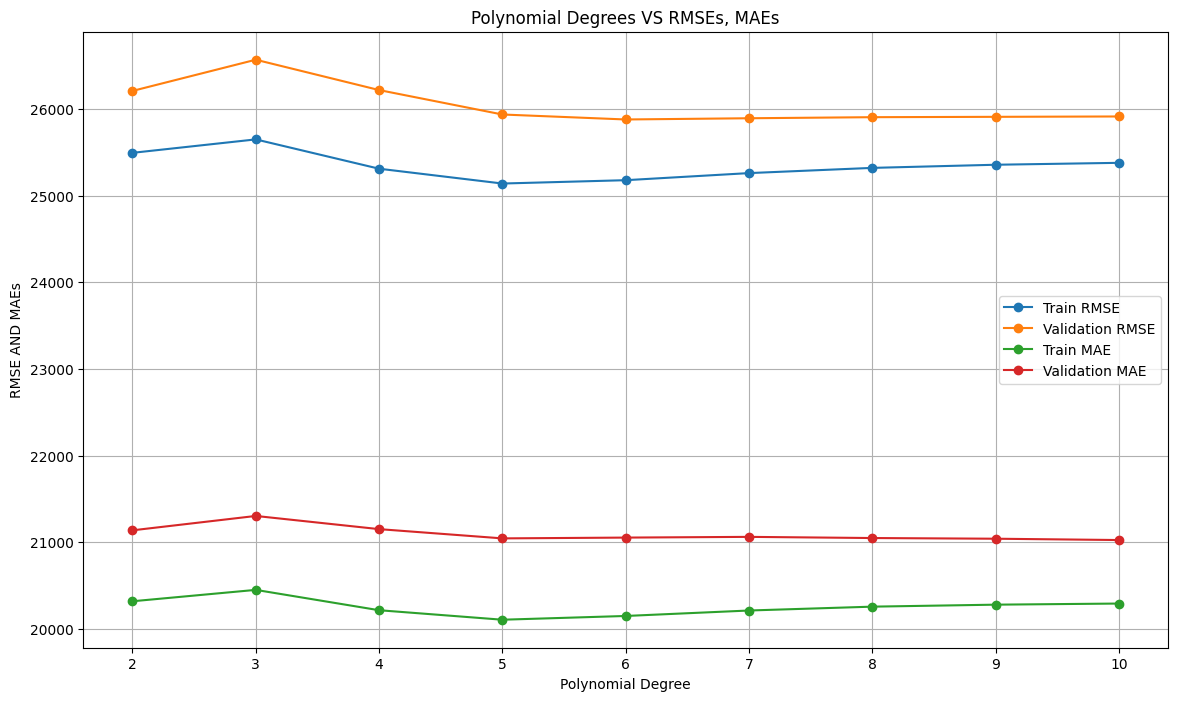

In [13]:
plt.figure(figsize=(14, 8))
plt.plot(results_df['degeree'], results_df['train_rmse'], marker='o', label='Train RMSE')
plt.plot(results_df['degeree'], results_df['val_rmse'], marker='o', label='Validation RMSE')
plt.plot(results_df['degeree'], results_df['train_mae'], marker='o', label='Train MAE')
plt.plot(results_df['degeree'], results_df['val_mae'], marker='o', label='Validation MAE')
plt.title("Polynomial Degrees VS RMSEs, MAEs")
plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE AND MAEs")
plt.legend()
plt.grid()
plt.show()

the best Polynomial Feature is 5

In [16]:
best_poly_degree = 5

X_train_best_poly = add_polynomial_features(X_train, degree=5)
X_test_best_poly = add_polynomial_features(X_test, degree=5)

X_train_best_poly_stand, X_test_best_poly_stand = scaling(X_train_best_poly, X_test_best_poly)

best_poly_model = LinearRegression(
    learning_rate=1e-2,
    iterations=600,
    method='batch',
    cost_function='mse'

)

best_poly_model.fit(X_train_best_poly_stand, y_train)

C:\Users\k\AppData\Local\Temp\ipykernel_27796\2183401696.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


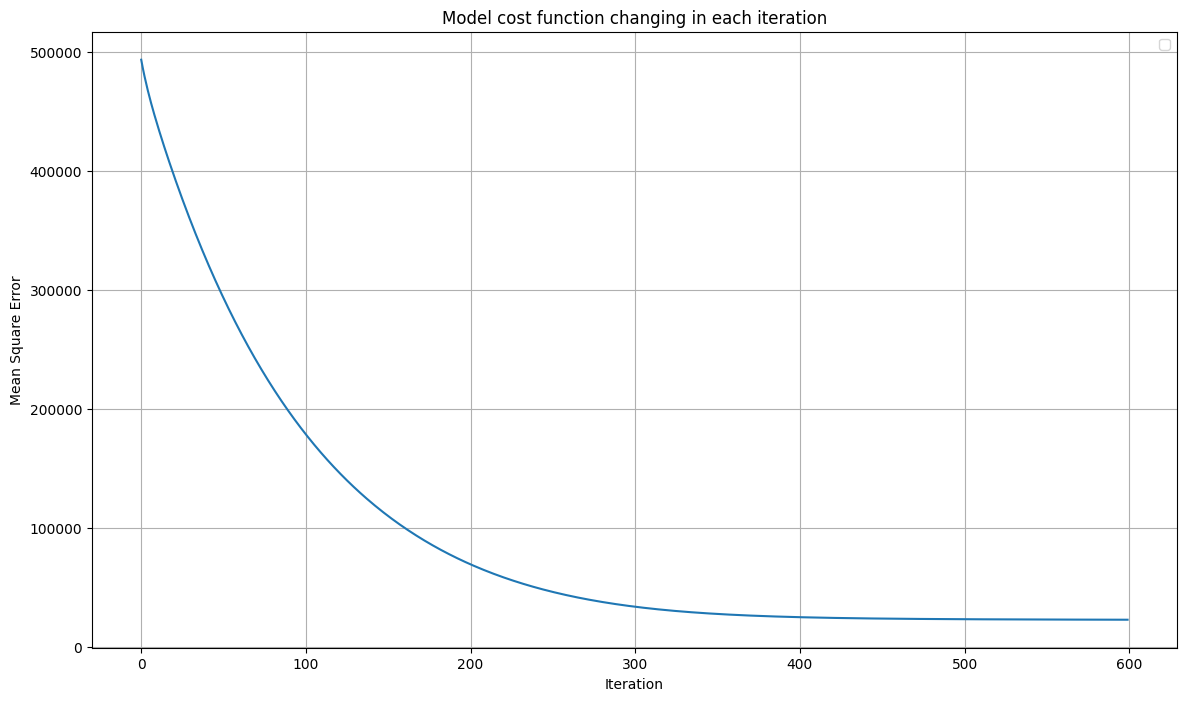

In [15]:
iterations = [item[0] for item in best_poly_model.rmse_costs]
cost_values = [item[1] for item in best_poly_model.rmse_costs]

plt.figure(figsize=(14, 8))
plt.plot(iterations, cost_values)
plt.title("Model cost function changing in each iteration")
plt.xlabel("Iteration")
plt.ylabel("Mean Square Error")
plt.grid()
plt.legend()
plt.show()

In [16]:
train_predictions_best_poly_model = best_poly_model.predict(X_train_best_poly_stand)
test_predictions_best_poly_model = best_poly_model.predict(X_test_best_poly_stand)

In [17]:
train_rmse_best_poly_model = RootMeanSquaredError(y_train, train_predictions_best_poly_model)
test_rmse_best_poly_model = RootMeanSquaredError(y_test, test_predictions_best_poly_model)

print(f"Best Poly model's Root Mean Squared Error On train set {train_rmse_best_poly_model}")
print(f"Best Poly model's Root Mean Squared Error on Test set {test_rmse_best_poly_model}")

Best Poly model's Root Mean Squared Error On train set 23015.882571026195
Best Poly model's Root Mean Squared Error on Test set 23571.74234402016


In [18]:
train_mse_best_poly_model = MeanSquaredError(y_train, train_predictions_best_poly_model)
test_mse_best_poly_model = MeanSquaredError(y_test, test_predictions_best_poly_model)
print(f"Best Poly Model's Mean Squared Error On train set {train_mse_best_poly_model}")
print(f"Best Poly Model's Mean Squared Error On test set {test_mse_best_poly_model}")

Best Poly Model's Mean Squared Error On train set 529730850.52326745
Best Poly Model's Mean Squared Error On test set 555627037.132873


In [19]:
train_mae_best_poly_model = MeanAbsoluteError(y_train, train_predictions_best_poly_model)
test_mae_best_poly_model = MeanAbsoluteError(y_test, test_predictions_best_poly_model)
print(f"Best Poly Model's Mean Absolute Error On train set {train_mae_best_poly_model}")
print(f"Best Poly Model's Mean Absolute Error On test set {test_mae_best_poly_model}")

Best Poly Model's Mean Absolute Error On train set 18383.16089320545
Best Poly Model's Mean Absolute Error On test set 18993.89809171055


## Regularizations

- **L1 Lasso Regression**
- **L2 Ridge Regression**
- **L1 + L2 Elastic Net**

### L1 Regularization (Lasso Regression)

In [24]:
class LassoRegression:
    def __init__(self, learnig_rate=0.001, iterations=1000, cost_function='mse', lambda_l=0.0001):
        self.learning_rate = learnig_rate
        self.iterations = iterations
        self.cost_function = cost_function
        self.lambda_l = lambda_l
        self.rmse_costs = []

    def fit(self, X, y):
        # Converting Data to Numpy array
        X = np.array(X, dtype=float)
        # Converting Tartget 1D array
        y = np.array(y, float).ravel()

        # num of samples and features
        n_samples, features = X.shape
        # initializing weights and bias
        self.weights = np.zeros(features)
        self.bias = 0
        

        for iter in range(self.iterations):
            # making predictions
            y_pred = np.dot(X, self.weights) + self.bias
            # errror
            error = y_pred - y
            if self.cost_function == 'mse':
                # calculating derivatives
                dw = (1 / n_samples) * np.dot(X.T, error) + self.lambda_l * np.sign(self.weights)
                db = (1 / n_samples) * np.sum(error)
            elif self.cost_function == 'mae':
                # calculating derivatives
                dw = (1 / n_samples) * np.dot(X.T, np.sign(error)) + self.lambda_l * np.sign(self.weights)
                db = (1 / n_samples) * np.sum(np.sign(error))

            else:
                raise ValueError("cost function must be either 'mse' or 'mae'")

            # updaint weights
            self.weights = self.weights - self.learning_rate * dw
            self.bias = self.bias - self.learning_rate * db 

            # storing costs 
            rmse = RootMeanSquaredError(y, y_pred)
            self.rmse_costs.append([iter, rmse])

    def predict(self, X_new):
        return np.dot(X_new, self.weights) + self.bias
            
                

In [79]:
L1_Model = LassoRegression(
    learnig_rate=0.1,
    iterations=1000,
    cost_function='mse',
    lambda_l=0.01
)

In [80]:
L1_Model.fit(X_train_best_poly_stand, y_train)

C:\Users\k\AppData\Local\Temp\ipykernel_27796\4017059244.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


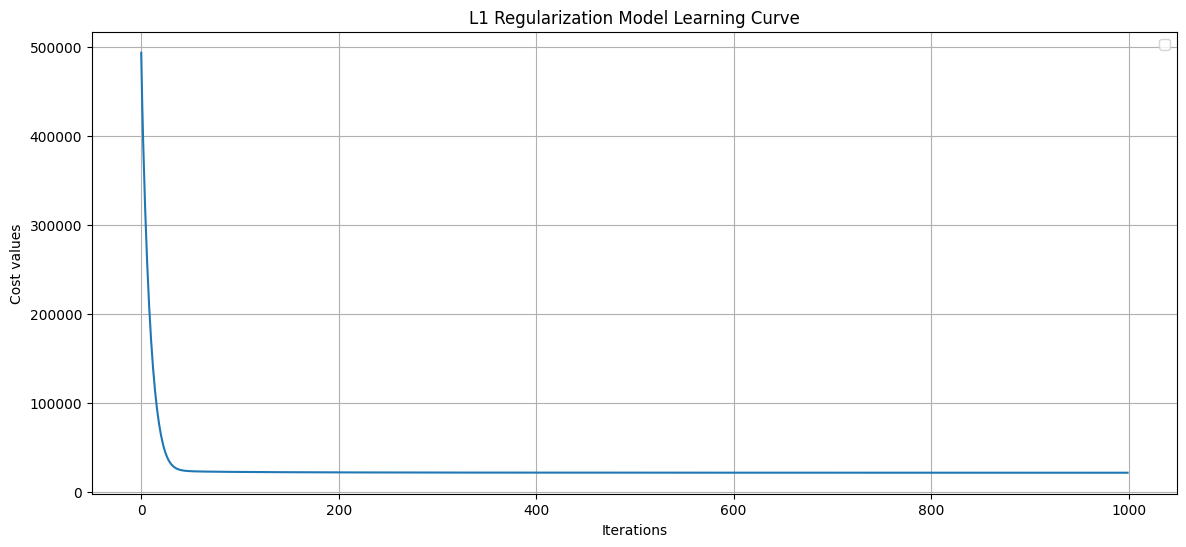

In [81]:
iterations = [item[0] for item in L1_Model.rmse_costs]
cost_values = [item[1] for item in L1_Model.rmse_costs]

plt.figure(figsize=(14, 6))
plt.plot(iterations, cost_values)
plt.title("L1 Regularization Model Learning Curve")
plt.xlabel("Iterations")
plt.ylabel("Cost values")
plt.legend()
plt.grid()
plt.show()

In [82]:
train_predictions_l1_model = L1_Model.predict(X_train_best_poly_stand)
test_predictions_l1_model = L1_Model.predict(X_test_best_poly_stand)

In [83]:
rmse_train_l1_model = RootMeanSquaredError(y_train, train_predictions_l1_model)
rmse_test_l1_model = RootMeanSquaredError(y_test, test_predictions_l1_model)

print("L1 Regularization Model Root Mean Squared Error on Train data:", rmse_train_l1_model)
print("L1 Regularization Model Root Mean Squared Error on Test data:", rmse_test_l1_model)

L1 Regularization Model Root Mean Squared Error on Train data: 21615.472774642003
L1 Regularization Model Root Mean Squared Error on Test data: 22158.675844810117


In [98]:
mae_train_l1_model = MeanAbsoluteError(y_train, train_predictions_l1_model)
mae_test_l1_model = MeanAbsoluteError(y_test, test_predictions_l1_model)


print("L1 Regularization Model Root Mean Absolute Error on Train data:", mae_train_l1_model)
print("L1 Regularization Model Root Mean Absolute Error on Test data:", mae_test_l1_model)

L1 Regularization Model Root Mean Absolute Error on Train data: 17239.696158125793
L1 Regularization Model Root Mean Absolute Error on Test data: 17869.930171262153


In [85]:
r2score_train_l1_model = R2Score(y_train, train_predictions_l1_model)
r2score_test_l1_model = R2Score(y_test, test_predictions_l1_model)

print("L1 Regularization Model R2 Score on Train data: ", r2score_train_l1_model)
print("L1 Regularization Model R2 Score on Test data: ", r2score_test_l1_model)

L1 Regularization Model R2 Score on Train data:  0.9605721992665276
L1 Regularization Model R2 Score on Test data:  0.9595533782250985


### L2 Reguralization (Ridge Regression)

In [40]:
class RidgeRegression:
    def __init__(self, learning_rate=0.001, iterations=1000, cost_function='mse', lambda_l=0.001):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.cost_function = cost_function
        self.lambda_l = lambda_l
        self.rmse_costs = []

    def fit(self, X, y):
        n_samples, features = X.shape
        self.weights = np.zeros(features)
        self.bias = 0

        for iter in range(self.iterations):
            y_pred = np.dot(X, self.weights) + self.bias
            error = y_pred - y
            dw = (1 / n_samples) * np.dot(X.T, error) + 2 * self.lambda_l * self.weights
            db = (1 / n_samples) * np.sum(error)
            self.weights = self.weights - self.learning_rate * dw
            self.bias = self.bias - self.learning_rate * db
            rmse = RootMeanSquaredError(y, y_pred)
            self.rmse_costs.append([iter, rmse])

    def predict(self, X_new):
        return np.dot(X_new, self.weights) + self.bias

In [41]:
L2_model = RidgeRegression(
    learning_rate=0.01,
    iterations=1000,
    lambda_l=0.001
)

In [42]:
L2_model.fit(X_train_best_poly_stand, y_train)

C:\Users\k\AppData\Local\Temp\ipykernel_8748\2904799916.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


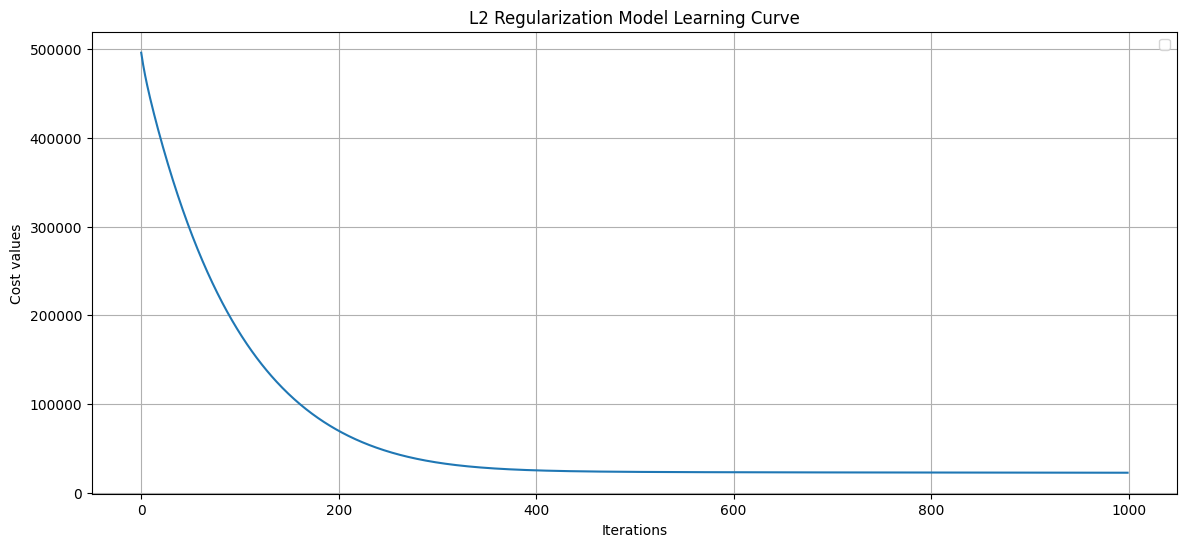

In [43]:
iterations = [item[0] for item in L2_model.rmse_costs]
cost_values = [item[1] for item in L2_model.rmse_costs]

plt.figure(figsize=(14, 6))
plt.plot(iterations, cost_values)
plt.title("L2 Regularization Model Learning Curve")
plt.xlabel("Iterations")
plt.ylabel("Cost values")
plt.legend()
plt.grid()
plt.show()

In [44]:
train_predictions_l2_model = L2_model.predict(X_train_best_poly_stand)
test_predictions_l2_model = L2_model.predict(X_test_best_poly_stand)

In [45]:
rmse_train_l2_model = RootMeanSquaredError(y_train, train_predictions_l2_model)
rmse_test_l2_model = RootMeanSquaredError(y_test, test_predictions_l2_model)

print("L2 Regularization Model Root Mean Squared Error on Train data:", rmse_train_l2_model)
print("L2 Regularization Model Root Mean Squared Error on Test data:", rmse_test_l2_model)

L2 Regularization Model Root Mean Squared Error on Train data: 22758.85410061677
L2 Regularization Model Root Mean Squared Error on Test data: 21791.17445982834


In [46]:
mae_train_l2_model = MeanAbsoluteError(y_train, train_predictions_l2_model)
mae_test_l2_model = MeanAbsoluteError(y_test, test_predictions_l2_model)

print("L2 Regularization Model Mean Absolute Error on Train data:", mae_train_l2_model)
print("L2 Regularization Model Mean Absolute Error on Test data:", mae_test_l2_model)

L2 Regularization Model Mean Absolute Error on Train data: 18227.26810603878
L2 Regularization Model Mean Absolute Error on Test data: 17408.679690664754


In [47]:
r2_score_l2_model_train = R2Score(y_train, train_predictions_l2_model)
r2_score_l2_model_test = R2Score(y_test, test_predictions_l2_model)

print("L2 Regularization R2 Score on Train data:", r2_score_l2_model_train)
print("L2 Regularization R2 score on Test data:", r2_score_l2_model_test)

L2 Regularization R2 Score on Train data: 0.9562830677571833
L2 Regularization R2 score on Test data: 0.9609927458463772


### L1 + L2 (Elastic Net)

In [50]:
class ElasticNet:
    def __init__(
            self, 
            learning_rate=0.001, 
            iterations=1000, 
            lambda_l1=0.0001, 
            lambda_l2=0.001
        ):
        self.learning_rate=learning_rate
        self.iterations=iterations
        # regularization strengths
        self.lambda_l1 = lambda_l1
        self.lambda_l2 = lambda_l2
        # Training history
        self.costs = []
        self.rmse_scores = []

    def fit(self, X, y):
        # Converting data to NumPy arrays
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).ravel()
        # Number of samples and features
        n_samples, n_features = X.shape
        # initialize weights and bias
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for iter in range(self.iterations):
            # make predictions
            y_pred = np.dot(X, self.weights) + self.bias
            # calculate error
            error = y_pred - y
            # MSE Gradient 
            mse_gradient = (1 / n_samples) * np.dot(X.T, error)
            # L1 Gradient 
            l1_gradient = self.lambda_l1 * np.sign(self.weights)
            # L2 Gradient
            l2_gradient = 2 * self.lambda_l2 * self.weights
            # Total Weight gradietn
            dw = mse_gradient + l1_gradient + l2_gradient
            # Bias Gradient 
            db = (1 / n_samples) * np.sum(error)
            # updating parameters
            self.weights = self.weights - self.learning_rate * dw
            self.bias = self.bias - self.learning_rate * db
            # predictions after update
            y_pred_updated = np.dot(X, self.weights) + self.bias
            # error after updated weights
            error_updated = y_pred_updated - y 
            # MSE cost 
            mse_cost = np.mean(error_updated ** 2) / 2
            # L1 penalty
            l1_penalty = self.lambda_l1 * np.sum(np.abs(self.weights))
            # L2 penalty
            l2_penalty = self.lambda_l2 * np.sum(self.weights ** 2)
            # Total Elastic Net cost
            total_cost = mse_cost + l1_penalty + l2_penalty
            # stroing Elastic Net cost
            self.costs.append([iter, total_cost])
            # calculate RMSE cost 
            rmse = RootMeanSquaredError(y_true=y, y_pred=y_pred_updated)
            # storing RMSE cost
            self.rmse_scores.append([iter, rmse])

    def predict(self, X_new):
        X_new = np.asarray(X_new, dtype=float)
        return np.dot(X_new, self.weights)+self.bias


In [60]:
ElasticNet_model = ElasticNet(
    learning_rate=0.01,
    iterations=1000,
    lambda_l1=0.0001,
    lambda_l2=0.001
)

In [61]:
ElasticNet_model.fit(X_train_best_poly_stand, y_train)

C:\Users\k\AppData\Local\Temp\ipykernel_8748\482235403.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


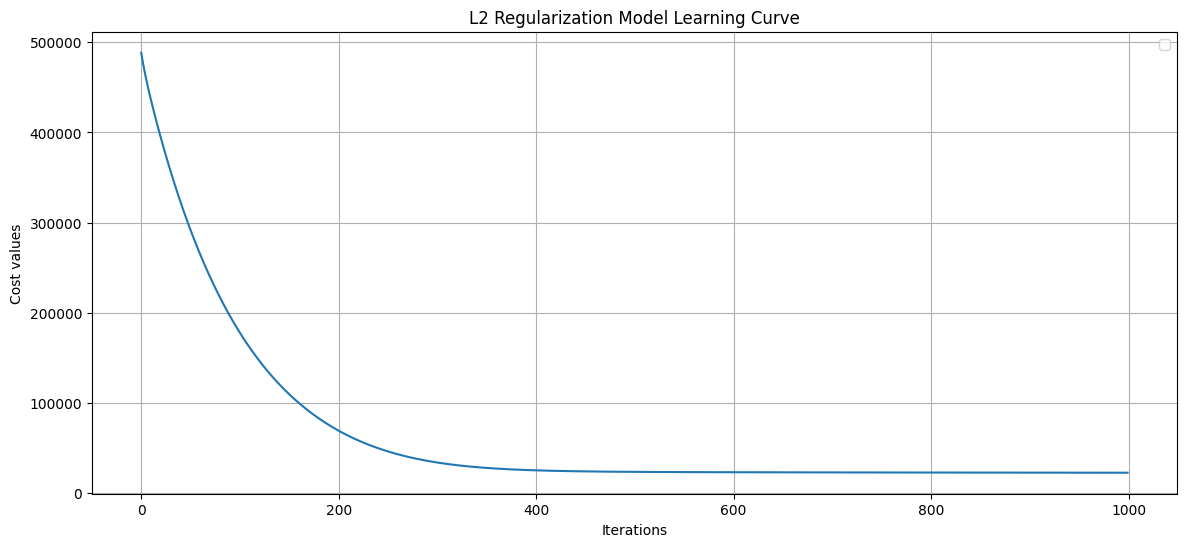

In [62]:
iterations = [item[0] for item in ElasticNet_model.rmse_scores]
cost_values = [item[1] for item in ElasticNet_model.rmse_scores]

plt.figure(figsize=(14, 6))
plt.plot(iterations, cost_values)
plt.title("L2 Regularization Model Learning Curve")
plt.xlabel("Iterations")
plt.ylabel("Cost values")
plt.legend()
plt.grid()
plt.show()

In [63]:
train_predictions_elasticnet_model = ElasticNet_model.predict(X_train_best_poly_stand)
test_predictions_elasticnet_model = ElasticNet_model.predict(X_test_best_poly_stand)

In [64]:
rmse_train_elasticnet_model = RootMeanSquaredError(y_train, train_predictions_elasticnet_model)
rmse_test_elasticnet_model = RootMeanSquaredError(y_test, test_predictions_elasticnet_model)

print("L2 Regularization Model Root Mean Squared Error on Train data:", rmse_train_elasticnet_model)
print("L2 Regularization Model Root Mean Squared Error on Test data:", rmse_test_elasticnet_model)

L2 Regularization Model Root Mean Squared Error on Train data: 22758.854069723206
L2 Regularization Model Root Mean Squared Error on Test data: 21791.174421056447


In [66]:
mae_train_elasticnet_model = MeanAbsoluteError(y_train, train_predictions_elasticnet_model)
mae_test_elasticnet_model = MeanAbsoluteError(y_test, test_predictions_elasticnet_model)

print("L2 Regularization Model Mean Absolute Error on Train data:", mae_train_elasticnet_model)
print("L2 Regularization Model Mean Absolute Error on Test data:", mae_test_elasticnet_model)

L2 Regularization Model Mean Absolute Error on Train data: 18227.26807018802
L2 Regularization Model Mean Absolute Error on Test data: 17408.679674499344


In [67]:
r2_score_elasticnet_model_train = R2Score(y_train, train_predictions_elasticnet_model)
r2_score_elasticnet_model_test = R2Score(y_test, test_predictions_elasticnet_model)

print("L2 Regularization R2 Score on Train data:", r2_score_elasticnet_model_train)
print("L2 Regularization R2 score on Test data:", r2_score_elasticnet_model_test)

L2 Regularization R2 Score on Train data: 0.9562830678758687
L2 Regularization R2 score on Test data: 0.9609927459851842
